In [2]:
import pandas as pd
import scipy
import numpy as np
import seaborn as sns
import cooler
import pybedtools
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.decomposition import PCA
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


In [3]:
# Matplotlib settings

plt.rc('font', family='Helvetica')
#mpl.rcParams['font.family']='Helvetica'

mpl.rc('lines', linewidth=0.4)

mpl.rc('font', family='Helvetica', size=8)

mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)

mpl.rc('legend', fontsize=8)

mpl.rc('xtick', labelsize=6)

mpl.rc('xtick.major', width=0.4, size=2)

mpl.rc('xtick.minor', width=0.4, size=1)

mpl.rc('ytick', labelsize=6)

mpl.rc('ytick.major', width=0.4, size=2)

mpl.rc('ytick.minor', width=0.4, size=1)

mpl.rcParams['font.family'] = 'Helvetica'

mpl.rc('lines', linewidth=0.4)


In [3]:
def norm(ff,ch):
    s=ff.matrix(balance=True).fetch(ch)
    D=np.zeros(len(s))
    for i in range (len(s)):
        D[i]=np.nanmean(s.diagonal(i))
     
    A=np.zeros((len(s),len(s)))
    n=len(s)
    for i in range (len(s)):
        row_id=np.arange(0,(n-i))
        col_id=np.arange(i,n)

        if D[i]!=0:
            A[row_id,col_id]=s[row_id,col_id]/D[i]
            A[col_id,row_id]=s[col_id,row_id]/D[i]

    return(A)


In [9]:
pcb=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/polycomb_dot_anchors.hand_made.filt_by_fithic.bedpe',sep='\t')

In [10]:
files=['Eres_iPSC_5kb.sampled_exact.mcool',
       'Artrial_D0_iPSC_5K.mcool',
       'Lu2020_iPSC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
    'Ballerino2022_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Rajarajan_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Zaghi2023_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Ballerino2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Li2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Rahman2023_iPSC_NeuNplus_CRISPRi_Scrambled_A_DpnII-HinfI.sampled_exact.mcool',
 'Wu2021_iPSC_NeuNplus.sampled_exact.mcool',
 'Zaghi2023_iPSC_NeuNplus.sampled_exact.mcool',
 'PsychENCODE_iPSC_NeuNplus.sampled_exact.mcool',
 'Lagarkova_culture_iPSC_NeuNplus.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Heffel_2T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Heffel_3T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Rahman2023_FetalBrain.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Heffel_infant.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',       
 'Heffel_adult.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Hu2021_NeuNplus.sampled_exact.mcool',
 'Pletenev2024_NeuNplus.sampled_exact.mcool',
 'Rahman2023_NeuNplus.sampled_exact.mcool',
 'Tian2023_NeuNplus.EN_IN.29_42_58_years.2000_cells.sampled_exact.mcool']


names=['Eres','Artrial','Lu','Ballarino_NPC','Rajarajan_NPC','Zaghi_NPC','Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag','Heffel(2T)','Heffel(3T)','Rahman(fetal)','Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']

k=0
polyc_df_all=pd.DataFrame()
back=pd.DataFrame()
dots=pd.DataFrame()

poly=pcb.copy()
poly.start1=(poly.start1/100000).astype(int)
poly.start2=(poly.start2/100000).astype(int)

for f in files:
    dots_x=[]
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/100000'%f)
    l=0
    for ch in np.unique(poly['chrom1']):
        tmp=poly.loc[poly['chrom1']==ch]
        m=c.matrix().fetch(ch)#norm(c,ch)#
        for i in range(len(tmp)):
            x=tmp.iloc[i]['start1']
            y=tmp.iloc[i]['start2']
            dots_x.append(m[x,y])
            l+=1
    dots[names[k]]=dots_x
    k+=1



/tmp/ipykernel_37010/1026795625.py:53: RuntimeWarning: Mean of empty slice
  scores.append(np.nanmean(m[x:x+1,y:y+1])/np.nanmean(m[x-5:x+6,y-5:y+6]))
/tmp/ipykernel_37010/1026795625.py:53: RuntimeWarning: Mean of empty slice
  scores.append(np.nanmean(m[x:x+1,y:y+1])/np.nanmean(m[x-5:x+6,y-5:y+6]))
/tmp/ipykernel_37010/1026795625.py:53: RuntimeWarning: Mean of empty slice
  scores.append(np.nanmean(m[x:x+1,y:y+1])/np.nanmean(m[x-5:x+6,y-5:y+6]))
/tmp/ipykernel_37010/1026795625.py:53: RuntimeWarning: Mean of empty slice
  scores.append(np.nanmean(m[x:x+1,y:y+1])/np.nanmean(m[x-5:x+6,y-5:y+6]))
/tmp/ipykernel_37010/1026795625.py:53: RuntimeWarning: Mean of empty slice
  scores.append(np.nanmean(m[x:x+1,y:y+1])/np.nanmean(m[x-5:x+6,y-5:y+6]))
/tmp/ipykernel_37010/1026795625.py:51: RuntimeWarning: Mean of empty slice
  back_x.append(np.nanmean(back_tmp))
/tmp/ipykernel_37010/1026795625.py:53: RuntimeWarning: Mean of empty slice
  scores.append(np.nanmean(m[x:x+1,y:y+1])/np.nanmean(m[x-5:x+

In [252]:

dz=dots.dropna().transpose()


for i in dz.columns:
    dz[i]=(dz[i]-dz.mean(axis=0)[i])/dz.std(axis=0)[i]



pca = PCA(n_components=5)

X=pca.fit(dz).transform(dz)

pca.explained_variance_ratio_




array([0.61960066, 0.05404291, 0.04351508, 0.03459147, 0.02944148])

In [253]:
ipsc='#469433'
fet='#9c2725'
pm='#034e91'
npc='#e38519'
sc='#696969'

In [199]:
pca_df=pd.DataFrame(X[:,0:2])

In [202]:
pca_df.index=['Eres','Artrial','Lu','Ballarino_NPC','Rajarajan_NPC','Zaghi_NPC','Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag','Heffel(2T)','Heffel(3T)','Rahman(fetal)','Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']

In [205]:
pca_df.columns=['PC1','PC2']

In [208]:
pca_df['group']=['iPSC']*3+['NPC']*3+['iPSC-derived neurons']*7+['Fetal neurons']*3+['Post-mortem neurons']*6

In [211]:
pca_df['sample_simple']=pca_df.index

In [212]:
pca_df.to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/PC1_PC2_data_for_polyc.txt',sep='\t',index=None)

In [255]:
dots.to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/polyc_dots_for_limma_normalized.txt',sep='\t',index=None)

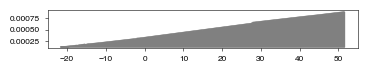

In [14]:
plt.figure(figsize=(4,0.5))
plt.plot(X[np.argsort(X[:,0]),0],dots.median()[np.argsort(X[:,0])],color='grey')

y1=dots.median()[np.argsort(X[:,0])]
x1=X[np.argsort(X[:,0]),0]

x2=[y1[0]]*len(x1)
plt.fill_between(x1,x2,y1,color='grey')
#plt.plot([y1[0],y1[15]],[y2[0],y2[15]])
plt.xlim(-25,55)
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/pcb_score_vs_PC1_no_any_normalization_all_cell_types.pdf')

In [125]:
neu_peak=pd.read_csv('/home/anna/Downloads/H3K27me3_Neuron.broadPeak',sep=' ',header=None)

neu_peak_bed=pybedtools.BedTool.from_dataframe(neu_peak[[0,1,2,6]])

In [201]:
gg=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/genes_coordinates_hg38.txt',sep='\t',header=None)
g_bed=pybedtools.BedTool.from_dataframe(gg[[0,6,6,3]])

/tmp/ipykernel_8273/1789143072.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gg.sort_values([0,6],inplace=True)
/tmp/ipykernel_8273/1789143072.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gg.drop_duplicates([0,1],keep='first',inplace=True)


In [894]:
files=['Eres_iPSC_5kb.sampled_exact.mcool',
       'Artrial_D0_iPSC_5K.mcool',
       'Lu2020_iPSC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
    'Ballerino2022_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Rajarajan_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Zaghi2023_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
    'Ballerino2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Li2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Rahman2023_iPSC_NeuNplus_CRISPRi_Scrambled_A_DpnII-HinfI.sampled_exact.mcool',
 'Wu2021_iPSC_NeuNplus.sampled_exact.mcool',
 'Zaghi2023_iPSC_NeuNplus.sampled_exact.mcool',
 'PsychENCODE_iPSC_NeuNplus.sampled_exact.mcool',
 'Lagarkova_culture_iPSC_NeuNplus.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Heffel_2T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Heffel_3T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Rahman2023_FetalBrain.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Heffel_infant.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',       
 'Heffel_adult.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Hu2021_NeuNplus.sampled_exact.mcool',
 'Pletenev2024_NeuNplus.sampled_exact.mcool',
 'Rahman2023_NeuNplus.sampled_exact.mcool',
 'Tian2023_NeuNplus.EN_IN.29_42_58_years.2000_cells.sampled_exact.mcool']


names=['Eres','Artrial','Lu','Ballerino(NPC)','Rajarajan(NPC)','Zaghi(NPC)','Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag','Heffel(2T)','Heffel(3T)','Rahman(fetal)','Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']

samples={}
poly=pcb.copy()
poly.start1=(poly.start1/20000).astype(int)
poly.start2=(poly.start2/20000).astype(int)

for f in files:
    scores=np.zeros((25,25,len(poly)))
    scores[:]=np.nan
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/20000'%f)
    l=0
    for ch in np.unique(poly['chrom1']):
        tmp=poly.loc[poly['chrom1']==ch]
        m=norm(c,ch)
        for i in range(len(tmp)):
            x=tmp.iloc[i]['start1']
            y=tmp.iloc[i]['start2']
            scores[:,:,l]=m[x-10:x+15,y-10:y+15]
            l+=1
            
    samples[names[k]]=scores
    k+=1


/tmp/ipykernel_37010/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_37010/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_37010/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_37010/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_37010/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_37010/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_37010/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_37010/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_37010/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_37010/337638316.py:5: RuntimeWa

['Eres', 'Artrial', 'Lu']
0.36776803113886325
['Ballerino(NPC)', 'Rajarajan(NPC)', 'Zaghi(NPC)']
0.027447590647633843
['Ballerino', 'Li', 'Rahman_iPSC', 'Wu', 'Zaghi', 'PsychENCODE', 'Lag']
0.0
['Heffel(2T)', 'Heffel(3T)', 'Rahman(fetal)']
0.5833791106997602
['Heffel(infant)', 'Heffel(adult)', 'Hu', 'Plet', 'Rahman', 'Tian']
0.8980876702911588


"\nfig.add_subplot(1,5,2)\nx1=[]\nfor f in f2:\n    x1.append(np.nanmean(samples[f],axis=2))\nx2=np.nanmean(x1,axis=0)  \nprint(np.mean(x2[10:15,10:15])/np.mean(x2[[0,1,2,3,4,20,21,22,23,24],:][:,[0,1,2,3,4,20,21,22,23,24]].flatten()))\n\nplt.imshow(np.log2(x2),cmap='coolwarm',vmin=0,vmax=2.9)\nplt.colorbar(shrink=0.6)\nplt.xticks([2,12,22],[-200,0,200])\nplt.yticks([2,12,22],[-200,0,200])\nplt.title('fetal, 2.11')\n\nfig.add_subplot(1,5,3)\nx1=[]\nfor f in f3:\n    x1.append(np.nanmean(samples[f],axis=2))\nx2=np.nanmean(x1,axis=0)  \nprint(np.mean(x2[10:15,10:15])/np.mean(x2[[0,1,2,3,4,20,21,22,23,24],:][:,[0,1,2,3,4,20,21,22,23,24]].flatten()))\nplt.imshow(np.log2(x2),cmap='coolwarm')#,vmin=0,vmax=2.9)\nplt.colorbar(shrink=0.6,label='average frequency\nof contacts, log2(obs/exp)')\nplt.xticks([2,12,22],[-200,0,200])\nplt.yticks([2,12,22],[-200,0,200])\nplt.title('post-mortem, 2.93')\n"

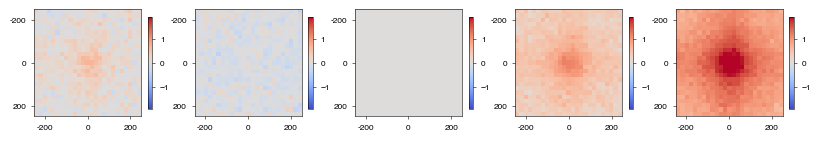

In [917]:
f1=['Eres','Artrial','Lu']
f2=['Ballerino(NPC)','Rajarajan(NPC)','Zaghi(NPC)']
f3=['Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag']
f4=['Heffel(2T)','Heffel(3T)','Rahman(fetal)']
f5=['Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']
k=1

x1=[]
for f in f3:
    x1.append(np.nanmean(samples[f],axis=2))
iPSCder=np.nanmean(x1,axis=0)  

fig=plt.figure(figsize=(10,2))
for clas in [f1,f2,f3,f4,f5]:
    fig.add_subplot(1,5,k)
    x1=[]
    for f in clas:
        x1.append(np.nanmean(samples[f],axis=2))
    x2=np.nanmean(x1,axis=0)
    print(clas)
    tt=x2.copy()/iPSCder.copy()
    
    tt[9:16,9:16]=np.nan
    back=np.nanmean(tt)
    tt0=x2.copy()/iPSCder.copy()
    print(np.log2(np.nanmean(tt0[10:15,10:15])/back))

    plt.imshow(np.log2(x2)-np.log2(iPSCder),cmap='coolwarm',vmin=-1.9,vmax=1.9)
    plt.colorbar(shrink=0.6)
    plt.xticks([2,12,22],[-200,0,200])
    plt.yticks([2,12,22],[-200,0,200])
    k+=1
#plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/polycomb_dots_heatmaps_all_diff_v2.pdf')

In [ ]:
##enrichment
'''
1.727570128603594
1.2919587694289028
1.298557085486109
2.113847155889247
2.9270263545838584
'''

In [1]:
################ EXPRESSION ##########################

In [372]:
pcb=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/polycomb_dot_anchors.hand_made.filt_by_fithic.bedpe',sep='\t')

In [373]:
polyc_score_coord=dots.copy()


In [374]:
start1=[]
start2=[]
chrom=[]
poly=pcb.copy()
for ch in np.unique(poly['chrom1']):
    tmp=poly.loc[poly['chrom1']==ch]
    for i in range(len(tmp)):
        x=tmp.iloc[i]['start1']
        y=tmp.iloc[i]['start2']
        start1.append(x)
        start2.append(y)
        chrom.append(ch)


polyc_score_coord['chrom']=chrom

polyc_score_coord['start1']=start1
polyc_score_coord['end1']=polyc_score_coord['start1']+100000

polyc_score_coord['start2']=start2
polyc_score_coord['end2']=polyc_score_coord['start2']+100000


In [80]:
#polyc_score_coord.to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/data_collegues/pcb_scores_coord.txt',sep='\t',index=None)

In [178]:
!!!!##############3enc_peak=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/ChIP-seq.H3K27me3.neurons.peaks.ENCFF104DEP.bed',sep='\t',header=None)

In [718]:
######################## scalings #############################

In [97]:
files=['Ballerino2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Li2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Rahman2023_iPSC_NeuNplus_CRISPRi_Scrambled_A_DpnII-HinfI.sampled_exact.mcool',
 'Wu2021_iPSC_NeuNplus.sampled_exact.mcool',
 'Zaghi2023_iPSC_NeuNplus.sampled_exact.mcool',
 'PsychENCODE_iPSC_NeuNplus.sampled_exact.mcool',
 'Lagarkova_culture_iPSC_NeuNplus.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Heffel_2T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Heffel_3T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Rahman2023_FetalBrain.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Heffel_infant.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',       
 'Heffel_adult.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Hu2021_NeuNplus.sampled_exact.mcool',
 'Pletenev2024_NeuNplus.sampled_exact.mcool',
 'Rahman2023_NeuNplus.sampled_exact.mcool',
 'Tian2023_NeuNplus.EN_IN.29_42_58_years.2000_cells.sampled_exact.mcool']

names=['Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag','Heffel(2T)','Heffel(3T)','Rahman(fetal)','Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']

names_labs=['Ballerino','Li','Rahman','Wu','Zaghi','Rajarajan','Our data','Heffel(2T)','Heffel(3T)','Rahman','Heffel(infant)','Heffel(adult)','Hu','Our data','Rahman','Tian']

samples={}  
k=0
raw_dots=pd.DataFrame()
poly=pcb.copy()
poly.start1=(poly.start1/100000).astype(int)
poly.start2=(poly.start2/100000).astype(int)

for f in files:
    scores=[]
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/100000'%f)
    for ch in np.unique(poly['chrom1']):
        tmp=poly.loc[poly['chrom1']==ch]
        m=c.matrix(balance=True).fetch(ch)
        for i in range(len(tmp)):
            x=tmp.iloc[i]['start1']
            y=tmp.iloc[i]['start2']
            scores.append(m[x,y])
    raw_dots[names[k]]=scores
    k+=1



In [572]:
files=['Ballerino2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Li2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Rahman2023_iPSC_NeuNplus_CRISPRi_Scrambled_A_DpnII-HinfI.sampled_exact.mcool',
 'Wu2021_iPSC_NeuNplus.sampled_exact.mcool',
 'Zaghi2023_iPSC_NeuNplus.sampled_exact.mcool',
 'PsychENCODE_iPSC_NeuNplus.sampled_exact.mcool',
 'Lagarkova_culture_iPSC_NeuNplus.drop_diag.5kb.mcool.sampled_exact.mcool']

c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/Ballerino2022_iPSC_NeuNplus.sampled_exact.mcool::resolutions/100000')
size=int(max(c.chromsizes)/100000)+1

stats_ipsc=pd.DataFrame()
n=0
for f in files:
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/100000'%f)
    diags_tmp={}  
    for i in range(0,size):
        diags_tmp[i]=[]

    for ch in chrs:
        m=c.matrix(balance=True).fetch(ch)
        for j in range(len(m)):
            diags_tmp[j]=diags_tmp[j]+list(np.diagonal(m,j))
    me=[]
    for k in diags_tmp.keys():
        me.append(np.nanmean(diags_tmp[k]))

    stats_ipsc[n]=me
    n+=1

       
files=['Heffel_infant.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',       
 'Heffel_adult.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Hu2021_NeuNplus.sampled_exact.mcool',
 'Pletenev2024_NeuNplus.sampled_exact.mcool',
 'Rahman2023_NeuNplus.sampled_exact.mcool',
 'Tian2023_NeuNplus.EN_IN.29_42_58_years.2000_cells.sampled_exact.mcool']
       
       
stats_pm=pd.DataFrame()
n=0
for f in files:
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/100000'%f)
    diags_tmp={}  
    for i in range(0,size):
        diags_tmp[i]=[]

    for ch in chrs:
        m=c.matrix(balance=True).fetch(ch)
        for j in range(len(m)):
            diags_tmp[j]=diags_tmp[j]+list(np.diagonal(m,j))
    me=[]
    for k in diags_tmp.keys():
        me.append(np.nanmean(diags_tmp[k]))

    stats_pm[n]=me
    n+=1
            
            
files=['Heffel_2T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Heffel_3T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Rahman2023_FetalBrain.drop_diag.5kb.mcool.sampled_exact.mcool']

stats_fetal=pd.DataFrame()
n=0
for f in files:
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/100000'%f)
    diags_tmp={}  
    for i in range(0,size):
        diags_tmp[i]=[]

    for ch in chrs:
        m=c.matrix(balance=True).fetch(ch)
        for j in range(len(m)):
            diags_tmp[j]=diags_tmp[j]+list(np.diagonal(m,j))
    me=[]
    for k in diags_tmp.keys():
        me.append(np.nanmean(diags_tmp[k]))

    stats_fetal[n]=me
    n+=1


/tmp/ipykernel_62243/2484626245.py:26: RuntimeWarning: Mean of empty slice
  me.append(np.nanmean(diags_tmp[k]))
/tmp/ipykernel_62243/2484626245.py:26: RuntimeWarning: Mean of empty slice
  me.append(np.nanmean(diags_tmp[k]))
/tmp/ipykernel_62243/2484626245.py:26: RuntimeWarning: Mean of empty slice
  me.append(np.nanmean(diags_tmp[k]))
/tmp/ipykernel_62243/2484626245.py:26: RuntimeWarning: Mean of empty slice
  me.append(np.nanmean(diags_tmp[k]))
/tmp/ipykernel_62243/2484626245.py:26: RuntimeWarning: Mean of empty slice
  me.append(np.nanmean(diags_tmp[k]))
/tmp/ipykernel_62243/2484626245.py:26: RuntimeWarning: Mean of empty slice
  me.append(np.nanmean(diags_tmp[k]))
/tmp/ipykernel_62243/2484626245.py:26: RuntimeWarning: Mean of empty slice
  me.append(np.nanmean(diags_tmp[k]))
/tmp/ipykernel_62243/2484626245.py:54: RuntimeWarning: Mean of empty slice
  me.append(np.nanmean(diags_tmp[k]))
/tmp/ipykernel_62243/2484626245.py:54: RuntimeWarning: Mean of empty slice
  me.append(np.nanmea

In [639]:
files=['Ballerino2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Li2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Rahman2023_iPSC_NeuNplus_CRISPRi_Scrambled_A_DpnII-HinfI.sampled_exact.mcool',
 'Wu2021_iPSC_NeuNplus.sampled_exact.mcool',
 'Zaghi2023_iPSC_NeuNplus.sampled_exact.mcool',
 'PsychENCODE_iPSC_NeuNplus.sampled_exact.mcool',
 'Lagarkova_culture_iPSC_NeuNplus.drop_diag.5kb.mcool.sampled_exact.mcool']

c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/Ballerino2022_iPSC_NeuNplus.sampled_exact.mcool::resolutions/100000')
size=int(max(c.chromsizes)/100000)+1

stats_polyc_ipsc=pd.DataFrame()
n=0
for f in files:
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/100000'%f)
    scores=[]
    for ch in np.unique(poly['chrom1']):
        tmp=poly.loc[poly['chrom1']==ch]
        m=c.matrix(balance=True).fetch(ch)
        for i in range(len(tmp)):
            x=tmp.iloc[i]['start1']
            y=tmp.iloc[i]['start2']
            scores.append(m[x,y])
    stats_polyc_ipsc[n]=scores
    n+=1
    
dist=[]
for ch in np.unique(poly['chrom1']):
    tmp=poly.loc[poly['chrom1']==ch]
    for i in range(len(tmp)):
        x=tmp.iloc[i]['start1']
        y=tmp.iloc[i]['start2']
        dist.append(abs(x-y))
stats_polyc_ipsc['dist']=dist


       
files=['Heffel_infant.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',       
 'Heffel_adult.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Hu2021_NeuNplus.sampled_exact.mcool',
 'Pletenev2024_NeuNplus.sampled_exact.mcool',
 'Rahman2023_NeuNplus.sampled_exact.mcool',
 'Tian2023_NeuNplus.EN_IN.29_42_58_years.2000_cells.sampled_exact.mcool']
       
       
stats_polyc_pm=pd.DataFrame()
n=0
for f in files:
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/100000'%f)
    scores=[]
    for ch in np.unique(poly['chrom1']):
        tmp=poly.loc[poly['chrom1']==ch]
        m=c.matrix(balance=True).fetch(ch)
        for i in range(len(tmp)):
            x=tmp.iloc[i]['start1']
            y=tmp.iloc[i]['start2']
            scores.append(m[x,y])
    stats_polyc_pm[n]=scores
    n+=1
    
dist=[]
for ch in np.unique(poly['chrom1']):
    tmp=poly.loc[poly['chrom1']==ch]
    for i in range(len(tmp)):
        x=tmp.iloc[i]['start1']
        y=tmp.iloc[i]['start2']
        dist.append(abs(x-y))
stats_polyc_pm['dist']=dist
            

files=['Heffel_2T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Heffel_3T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Rahman2023_FetalBrain.drop_diag.5kb.mcool.sampled_exact.mcool']

stats_polyc_fetal=pd.DataFrame()
n=0
for f in files:
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/100000'%f)
    scores=[]
    for ch in np.unique(poly['chrom1']):
        tmp=poly.loc[poly['chrom1']==ch]
        m=c.matrix(balance=True).fetch(ch)
        for i in range(len(tmp)):
            x=tmp.iloc[i]['start1']
            y=tmp.iloc[i]['start2']
            scores.append(m[x,y])
    stats_polyc_fetal[n]=scores
    n+=1
    
dist=[]
for ch in np.unique(poly['chrom1']):
    tmp=poly.loc[poly['chrom1']==ch]
    for i in range(len(tmp)):
        x=tmp.iloc[i]['start1']
        y=tmp.iloc[i]['start2']
        dist.append(abs(x-y))
stats_polyc_fetal['dist']=dist


In [640]:
stats_polyc_ipsc=stats_polyc_ipsc.groupby('dist').mean().reset_index()
stats_polyc_ipsc.index=stats_polyc_ipsc.dist

stats_polyc_pm=stats_polyc_pm.groupby('dist').mean().reset_index()
stats_polyc_pm.index=stats_polyc_pm.dist

stats_polyc_fetal=stats_polyc_fetal.groupby('dist').mean().reset_index()
stats_polyc_fetal.index=stats_polyc_fetal.dist

In [641]:
stats_polyc_fetal=stats_polyc_fetal[[0,1,2]]

In [642]:
stats_polyc_pm=stats_polyc_pm[[0, 1, 2, 3, 4, 5]]

In [643]:
stats_polyc_ipsc=stats_polyc_ipsc[[0, 1, 2, 3, 4, 5, 6]]

/home/anna/anaconda3/lib/python3.9/site-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


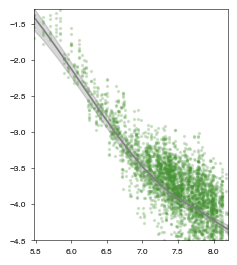

In [746]:
plt.figure(figsize=(2.5,3))
stats_ipsc.dropna(inplace=True)
stats_ipsc=stats_ipsc.loc[stats_ipsc.mean(axis=1)-stats_ipsc.std(axis=1)>0]
y=np.log10(stats_ipsc.mean(axis=1))
l=np.log10(stats_ipsc.mean(axis=1)-stats_ipsc.std(axis=1))
u=np.log10(stats_ipsc.mean(axis=1)+stats_ipsc.std(axis=1))
x= np.log10((stats_ipsc.index+1)*100000)
xnew=np.arange(np.min(x),np.max(x),0.2)

ax=plt.gca()
tck_l = splrep(x, l, s=1)
tck_u = splrep(x, u, s=1)
tck = splrep(x, y, s=1)
ax.plot(xnew, BSpline(*tck)(xnew),c='grey')
ax.fill_between(xnew, BSpline(*tck_l)(xnew),BSpline(*tck_u)(xnew),alpha=0.3,color='grey')



###########################
ipsc_test=np.log10(stats_polyc_ipsc).copy()
ipsc_test[np.isinf(ipsc_test)]=np.nan
ipsc_test.dropna(inplace=True)
y=ipsc_test.mean(axis=1)

x= np.log10((ipsc_test.index)*100000)
ax=plt.gca()
for n in ipsc_test.columns:
    ax.scatter(x,ipsc_test[n],s=2,alpha=0.2,c=ipsc)


plt.ylim(-4.5,-1.3)
plt.xlim(min(x),max(x))
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/ipsc_scalings.pdf')

/home/anna/anaconda3/lib/python3.9/site-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


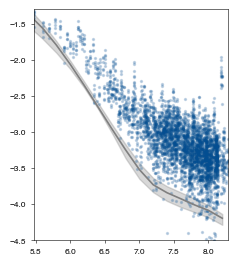

In [749]:
plt.figure(figsize=(2.5,3))
stats_pm.dropna(inplace=True)
stats_pm=stats_pm.loc[stats_pm.mean(axis=1)-stats_pm.std(axis=1)>0]
y=np.log10(stats_pm.mean(axis=1))
l=np.log10(stats_pm.mean(axis=1)-stats_pm.std(axis=1))
u=np.log10(stats_pm.mean(axis=1)+stats_pm.std(axis=1))
x= np.log10((stats_pm.index+1)*100000)
xnew=np.arange(np.min(x),np.max(x),0.2)

ax=plt.gca()
tck_l = splrep(x, l, s=1)
tck_u = splrep(x, u, s=1)
tck = splrep(x, y, s=1)
ax.plot(xnew, BSpline(*tck)(xnew),c='grey')
ax.fill_between(xnew, BSpline(*tck_l)(xnew),BSpline(*tck_u)(xnew),alpha=0.3,color='grey')



###########################
pm_test=np.log10(stats_polyc_pm).copy()
pm_test[np.isinf(pm_test)]=np.nan
pm_test.dropna(inplace=True)

y=pm_test.mean(axis=1)
x= np.log10((pm_test.index)*100000)

ax=plt.gca()
#ax.scatter(x, y,c=pm,s=2,alpha=0.6)
for n in pm_test.columns:
    ax.scatter(x,pm_test[n],s=2,alpha=0.2,c=pm)


plt.xlim(min(x),max(x))
plt.ylim(-4.5,-1.3)

plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/pm_scalings.pdf')

In [2120]:
######################### dea genes and pcb-score ####################

In [ ]:
expr=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/rlog_protein_coding_cortex_all_blind_true.txt',sep='\t',index_col=0)


In [ ]:
c1=pybedtools.BedTool.from_dataframe(polyc_score_coord[['chrom1','start1','end1']])
c2=pybedtools.BedTool.from_dataframe(polyc_score_coord[['chrom1','start2','end2']])

gene1=g_bed.intersect(c1)
gene1=gene1.intersect(neu_peak_bed).to_dataframe()

gene2=g_bed.intersect(c2)
gene2=gene2.intersect(neu_peak_bed).to_dataframe()

polyc_genes=pd.concat([gene1[['name']],gene2[['name']]])
polyc_genes.index=polyc_genes.name

In [ ]:
pcb_genes=set(expr.index)&set(polyc_genes.index)

In [182]:
cult_up=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/dea_genes_pcb_fc_more0_in_cult.txt',header=None)

In [183]:
cult_down=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/dea_genes_pcb_fc_less0_in_cult.txt',header=None)

In [193]:
ns=list(pcb_genes-set(cult_down[0])-set(cult_up[0]))


In [49]:
tmp=pd.DataFrame({0:ns})

In [166]:
tmp.to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/dea_genes_pcb_non_sign_genes.txt',header=None,index=None)

In [202]:
coord1=polyc_score_coord[['chrom','start1','end1']]
coord1['ids']=coord1.index

coord2=polyc_score_coord[['chrom','start2','end2']]
coord2['ids']=coord2.index

/tmp/ipykernel_1263107/748376472.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coord1['ids']=coord1.index
/tmp/ipykernel_1263107/748376472.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coord2['ids']=coord2.index


In [203]:
coord1_bed=pybedtools.BedTool.from_dataframe(coord1)
coord2_bed=pybedtools.BedTool.from_dataframe(coord2)

In [204]:
df1=coord1_bed.intersect(g_bed,wao=True).to_dataframe()

In [205]:
ns_neu_ids1=df1.loc[df1.thickEnd.isin(ns),'name']

In [206]:
up_neu_ids1=df1.loc[df1.thickEnd.isin(cult_up[0]),'name']

In [207]:
down_neu_ids1=df1.loc[(df1.thickEnd.isin(cult_down[0])),'name']

In [208]:
df1=coord2_bed.intersect(g_bed,wao=True).to_dataframe()

ns_neu_ids2=df1.loc[df1.thickEnd.isin(ns),'name']

up_neu_ids2=df1.loc[df1.thickEnd.isin(cult_up[0]),'name']

down_neu_ids2=df1.loc[(df1.thickEnd.isin(cult_down[0])),'name']

In [209]:
ns_ids=set(list(ns_neu_ids1)+list(ns_neu_ids2))
up_ids=set(list(up_neu_ids1)+list(up_neu_ids2))
down_ids=set(list(down_neu_ids1)+list(down_neu_ids2))

In [262]:
ns_ids_exc=set(ns_ids)-set(up_ids)-set(down_ids)

In [263]:
up_ids_exc=set(up_ids)-set(down_ids)-set(ns_ids)

In [264]:
down_ids_exc=set(down_ids)-set(up_ids)-set(ns_ids)

In [265]:
ns_cult=polyc_score_coord.loc[ns_ids_exc][['Ballerino', 'Li', 'Rahman_iPSC', 'Wu', 'Zaghi', 'PsychENCODE', 'Lag']].mean(axis=1)
ns_pm=polyc_score_coord.loc[ns_ids_exc][['Heffel(infant)','Heffel(adult)', 'Hu', 'Plet', 'Rahman', 'Tian']].mean(axis=1)
up_cult=polyc_score_coord.loc[up_ids_exc][['Ballerino', 'Li', 'Rahman_iPSC', 'Wu', 'Zaghi', 'PsychENCODE', 'Lag']].mean(axis=1)
up_pm=polyc_score_coord.loc[up_ids_exc][['Heffel(infant)','Heffel(adult)', 'Hu', 'Plet', 'Rahman', 'Tian']].mean(axis=1)
down_cult=polyc_score_coord.loc[down_ids_exc][['Ballerino', 'Li', 'Rahman_iPSC', 'Wu', 'Zaghi', 'PsychENCODE', 'Lag']].mean(axis=1)
down_pm=polyc_score_coord.loc[down_ids_exc][['Heffel(infant)','Heffel(adult)', 'Hu', 'Plet', 'Rahman', 'Tian']].mean(axis=1)

/tmp/ipykernel_1263107/2660809179.py:1: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  ns_cult=polyc_score_coord.loc[ns_ids_exc][['Ballerino', 'Li', 'Rahman_iPSC', 'Wu', 'Zaghi', 'PsychENCODE', 'Lag']].mean(axis=1)
/tmp/ipykernel_1263107/2660809179.py:2: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  ns_pm=polyc_score_coord.loc[ns_ids_exc][['Heffel(infant)','Heffel(adult)', 'Hu', 'Plet', 'Rahman', 'Tian']].mean(axis=1)
/tmp/ipykernel_1263107/2660809179.py:3: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  up_cult=polyc_score_coord.loc[up_ids_exc][['Ballerino', 'Li', 'Rahman_iPSC', 'Wu', 'Zaghi', 'PsychENCODE', 'Lag']].mean(axis=1)
/tmp/ipykernel_1263107/2660809179.py:4: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  up_

/tmp/ipykernel_1263107/845387081.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a=sns.boxplot(data=my_df, y='PcB-score',x='group of genes',palette=pal,
/tmp/ipykernel_1263107/845387081.py:16: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  a=sns.boxplot(data=my_df, y='PcB-score',x='group of genes',palette=pal,
/tmp/ipykernel_1263107/845387081.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=my_df, y='PcB-score',x='group of genes',s=1,palette=pal)
/tmp/ipykernel_1263107/845387081.py:23: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable 

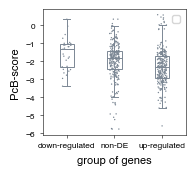

In [269]:
data=[np.log2(down_cult/down_pm),np.log2(ns_cult/ns_pm),np.log2(up_cult/up_pm)]
my_df=pd.DataFrame()

y1=[]

for i in data:
    y1=y1+list(i)
y2=['down-regulated']*len(data[0])+['non-DE']*len(data[1])+['up-regulated']*len(data[2])

my_df['PcB-score']=y1
my_df['group of genes']=y2

pal=[[123/256,136/256,149/256]]
plt.figure(figsize=(2.,1.8))

a=sns.boxplot(data=my_df, y='PcB-score',x='group of genes',palette=pal,
           linewidth=0.7,width=0.3,fliersize=0.3,showfliers=False,
             boxprops={'facecolor':'white', 'edgecolor':pal[0]},
        medianprops={'color':pal[0]},
        whiskerprops={'color':pal[0]},
        capprops={'color':pal[0]} )
sns.stripplot(data=my_df, y='PcB-score',x='group of genes',s=1,palette=pal) 
x1, x2 = -0.25,0.25
plt.tight_layout()
plt.legend('')
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/score_in_gene_groups_v6.pdf')


In [267]:
scipy.stats.mannwhitneyu(down_cult/down_pm,ns_cult/ns_pm,alternative='greater')

MannwhitneyuResult(statistic=4360.0, pvalue=0.030708769332713607)

In [268]:
scipy.stats.mannwhitneyu(ns_cult/ns_pm,up_cult/up_pm,alternative='greater')

MannwhitneyuResult(statistic=43416.0, pvalue=2.0657193296445904e-08)

In [676]:
############### polycomb and H3K27me3 ##############

In [11]:
pcb=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/polycomb_dot_anchors.hand_made.filt_by_fithic.bedpe',sep='\t')

In [12]:
pcb1=pcb[['chrom1','start1','end1']]
pcb2=pcb[['chrom2','start2','end2']]
pcb1['ids']=pcb1.index
pcb2['ids']=pcb2.index

/tmp/ipykernel_37010/2049172461.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pcb1['ids']=pcb1.index
/tmp/ipykernel_37010/2049172461.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pcb2['ids']=pcb2.index


In [13]:
pcb1_bed=pybedtools.BedTool.from_dataframe(pcb1)
pcb2_bed=pybedtools.BedTool.from_dataframe(pcb2)

In [204]:
cult_broad1=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/H3K27me3/broad_peaks/CnR_H3K27me3_D53_peaks.broadPeak',sep='\t',header=None)
cult_broad2=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/H3K27me3/broad_peaks/Wu_H3K27me3_REP1_peaks.broadPeak',sep='\t',header=None)


In [205]:
cult_broad=pd.concat([cult_broad1,cult_broad2])
cult_broad.sort_values([0,1,2],inplace=True)

In [206]:
cult_broad_bed=pybedtools.BedTool.from_dataframe(cult_broad)
cult_broad_bed=cult_broad_bed.merge()

In [ ]:
neu_broad1=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/H3K27me3/broad_peaks/H276_GLU_REP1_peaks.broadPeak',sep='\t',header=None)
neu_broad2=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/H3K27me3/broad_peaks/H372_GLU_REP1_peaks.broadPeak',sep='\t',header=None)
neu_broad3=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/H3K27me3/broad_peaks/H276_GABA_REP1_peaks.broadPeak',sep='\t',header=None)
neu_broad4=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/H3K27me3/broad_peaks/H372_GABA_REP1_peaks.broadPeak',sep='\t',header=None)


neu_broad=pd.concat([neu_broad1,neu_broad2,neu_broad3,neu_broad4])
neu_broad.sort_values([0,1,2],inplace=True)

neu_broad_bed=pybedtools.BedTool.from_dataframe(neu_broad)
neu_broad_bed=neu_broad_bed.merge()


In [41]:
##########################################

In [1225]:
polyc_score_coord=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/data_collegues/pcb_scores_coord.txt',sep='\t')

In [1226]:
polyc_score_coord['index']=polyc_score_coord.index

In [1227]:
pcb1_bed=pybedtools.BedTool.from_dataframe(polyc_score_coord[['chrom','start1','end1','index']])
pcb2_bed=pybedtools.BedTool.from_dataframe(polyc_score_coord[['chrom','start2','end2','index']])

In [1228]:
gg=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/genes_coordinates_hg38.txt',sep='\t',header=None)

In [1229]:
g_bed=pybedtools.BedTool.from_dataframe(gg[[0,6,6,3]])

In [1230]:
g_bed=g_bed.intersect(neu_peak_bed)

In [1231]:
x1=pcb1_bed.intersect(g_bed,wao=True).to_dataframe()
x2=pcb2_bed.intersect(g_bed,wao=True).to_dataframe()

In [1232]:
expr_tpm=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/all_cortex_blind_true_TPM.txt',sep='\t')
expr_tpm['pm']=np.nanmean(expr_tpm[['acc_rous', 'dlpfc_rous', 'riz']],axis=1)


In [1233]:
ids_of_genes_with_tpm_less1_in_pm=expr_tpm.loc[expr_tpm.pm<1].index

In [1234]:
expr=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/RNAseq_new/rlog_all_cortex_all_blind_true.txt',sep='\t',index_col=0)

expr['pm']=np.nanmean(expr[['ACC_Roussos', 'DLPFC_Roussos', 'Rizzardi']],axis=1)
expr['iPSCder']=np.nanmean(expr[['Li_iPSCder', 'Lu_iPSCder','PRJNA_iPSCder', 'Zaghi_iPSCder', 'Ciceri50_iPSCder']],axis=1)
expr=expr[['iPSCder','pm']]

In [1235]:
expr_low_in_pm=expr.loc[ids_of_genes_with_tpm_less1_in_pm]

In [1236]:
expr_low_in_both=expr_low_in_pm.loc[expr_low_in_pm.iPSCder<=expr_low_in_pm.pm]

In [1237]:
expr_high=expr.loc[~expr.index.isin(expr_low_in_both.index)]

In [1238]:
pcb1_with_high_expr=x1.loc[x1.thickEnd.isin(expr_high.index),'name']

In [1239]:
pcb1_with_high_expr=np.unique(pcb1_with_high_expr)

In [1240]:
pcb2_with_high_expr=x2.loc[x2.thickEnd.isin(expr_high.index),'name']

pcb2_with_high_expr=np.unique(pcb2_with_high_expr)

In [1241]:
good_ids=set(pcb.index)-set(pcb1_with_high_expr)-set(pcb2_with_high_expr)

In [1252]:
zz=polyc_score_coord.loc[good_ids]

/tmp/ipykernel_188758/2693087836.py:1: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  zz=polyc_score_coord.loc[good_ids]


In [1253]:
zz['iPSCder']=np.nanmean(zz[['Ballerino', 'Li', 'Rahman_iPSC', 'Wu', 'Zaghi', 'PsychENCODE', 'Lag']],axis=1)
zz['pm']=np.nanmean(zz[['Heffel(infant)',
       'Heffel(adult)', 'Hu', 'Plet', 'Rahman', 'Tian']],axis=1)

/tmp/ipykernel_188758/855711008.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=my_df,x="percentile of distance", y="PcB contact frequency,\nlog2(Post-mortem/iPSC-derived)",palette=pal, linewidth=0.5,fliersize=0.5,whis=0.7,width=0.6)
/tmp/ipykernel_188758/855711008.py:14: UserWarning: The palette list has more values (3) than needed (1), which may not be intended.
  sns.boxplot(data=my_df,x="percentile of distance", y="PcB contact frequency,\nlog2(Post-mortem/iPSC-derived)",palette=pal, linewidth=0.5,fliersize=0.5,whis=0.7,width=0.6)


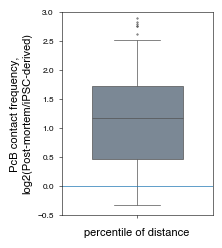

In [1259]:
data=[zz.pm-zz.iPSCder]
plt.figure(figsize=(2.15,2.5))
my_df=pd.DataFrame()
t1=[]
t2=[]
for i in data:
    t1=t1+list(i)
t2=['']*len(data[0])

my_df['PcB contact frequency,\nlog2(Post-mortem/iPSC-derived)']=t1
my_df['percentile of distance']=t2

pal=['lightslategrey','lightslategrey','lightslategrey']
sns.boxplot(data=my_df,x="percentile of distance", y="PcB contact frequency,\nlog2(Post-mortem/iPSC-derived)",palette=pal, linewidth=0.5,fliersize=0.5,whis=0.7,width=0.6)
plt.tight_layout()
plt.ylim(-0.5,3)
plt.axhline(0,lw=0.5)

plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/pcb_contact_frequency_ratio_for_low_expr_new_one_box.pdf')



In [1260]:
scipy.stats.wilcoxon(zz.pm,zz.iPSCder)

WilcoxonResult(statistic=66.0, pvalue=1.2587632412943242e-17)

In [1318]:
################## H3K27me3 ##################

In [118]:
path='/media/anna/Samsung_T5/culture_vs_postmortem/H3K27me3/'

files=['1238_control_DLPFC_NEUN_REP1_5K_new_scale.bedgraph',
'1238_H3K27me3_DLPFC_NEUN_REP1_5K_new_scale.bedgraph',
'1242_control_DLPFC_NEUN_REP1_5K_new_scale.bedgraph',
'1242_H3K27me3_DLPFC_NEUN_REP1_5K_new_scale.bedgraph',
    'GABA_IgG_REP1_5K_new_scale.bedgraph',
'GABA_REP1_5K_new_scale.bedgraph',
'GABA_IgG_REP2_5K_new_scale.bedgraph',
'GABA_REP2_5K_new_scale.bedgraph',
'GLU_IgG_REP1_5K_new_scale.bedgraph',
'GLU_REP1_5K_new_scale.bedgraph',
'GLU_IgG_REP2_5K_new_scale.bedgraph',
'GLU_REP2_5K_new_scale.bedgraph',
'H1_input_REP1_5K_new_scale_all_sorted.bedgraph',
'H1_signal_REP1_5K_new_scale_all_sorted.bedgraph',
'H9_input_REP1_5K_new_scale_all_sorted.bedgraph',
'H9_signal_REP1_5K_new_scale_all_sorted.bedgraph',
'CnR_IgG_D53_5K_new_scale.bedgraph',
'CnR_H3K27me3_D53_5K_new_scale.bedgraph',
'Wu_IgG_5K_new_scale.bedgraph',
'Wu_H3K27me3_5K_new_scale.bedgraph']


df=pd.DataFrame()
names=['1238_control','1238_signal','1242_control','1242_signal','GABA_control1','GABA_signal1','GABA_control2','GABA_signal2',
       'GLU_control1','GLU_signal1','GLU_control2','GLU_signal2',
       'H1_input','H1_signal','H9_input','H9_signal','Ciceri_input','Ciceri_signal','Wu_input','Wu_signal']
k=0
for f in files:
    g=pd.read_csv(path+'%s'%f,sep='\t',header=None)
    df[names[k]]=g[3]
    print(len(g))
    k+=1
    
a=np.array(df)
a=a.flatten()
a=a[~np.isnan(a)]
a=a[a>0]
minim=np.percentile(a,[1])

df['NEU_1238']=(df['1238_signal']+minim)/(df['1238_control']+minim)
df['NEU_1242']=(df['1242_signal']+minim)/(df['1242_control']+minim)
df['GABA1']=(df['GABA_signal1']+minim)/(df['GABA_control1']+minim)
df['GABA2']=(df['GABA_signal2']+minim)/(df['GABA_control2']+minim)
df['GLU1']=(df['GLU_signal1']+minim)/(df['GLU_control1']+minim)
df['GLU2']=(df['GLU_signal2']+minim)/(df['GLU_control2']+minim)
df['CULT1']=(df['H9_signal']+minim)/(df['H9_input']+minim)
df['CULT2']=(df['H1_signal']+minim)/(df['H1_input']+minim)
df['CULT3']=(df['Ciceri_signal']+minim)/(df['Ciceri_input']+minim)
df['CULT4']=(df['Wu_signal']+minim)/(df['Wu_input']+minim)


df=pd.concat([g[[0,1,2]],df],axis=1)



df['NEU_mean']=np.nanmean(df[['GABA1','GABA2','GLU1','GLU2']],axis=1)
df['CULT_mean']=np.nanmean(df[['CULT2','CULT3']],axis=1)
df['NEU_mean_GABA']=np.nanmean(df[['GABA1','GABA2']],axis=1)
df['NEU_mean_GLU']=np.nanmean(df[['GLU1','GLU2']],axis=1)


617669
617669
617669
617669
617669
617669
617669
617669
617669
617669
617669
617669
617669
617669
617669
617669
617669
617669
617669
617669


In [989]:
def pylap_new(path_to_points,df,nbins,chrs,res,chrom_dict):
    #Q=0
    points=pd.read_csv(path_to_points,sep='\t',header=None)
    chr_length=chrom_dict
    
    points.columns=['chrom','start','end']

    for i in list(chr_length.keys()):

        points=points.drop(points[(points['chrom']==i) & (points['start']>chr_length[i]-nbins*res)].index)

    h=points[points['start']>=nbins*res]
    h.sort_values(['chrom','start'],inplace=True)

    points=pybedtools.BedTool.from_dataframe(h)
    path=df.copy()#pd.read_csv(path_to_data,sep='\t',header=None)
    data=pybedtools.BedTool.from_dataframe(path)
    t=data.intersect(points,wao=True).to_dataframe()

    t= t.loc[t['chrom'].isin(chrs)]
    t.loc[t.name=='.','name']=np.nan
    q=sum(t['strand']!=-1)

    n=np.zeros((q,2*nbins+1))
    k=0
    for i in chrs:
       
        tmp=t[t['chrom']==i]
       
        tmp=tmp.reset_index(drop=True)
        for j in range(len(tmp)):

            if tmp.loc[j]['strand']!=-1:
                n[k]=tmp.loc[j-nbins:j+nbins]['name']
                
                k+=1
            
    A=pd.DataFrame(n)
    return(A)



def plott(xx,lab,m,colo,alp,legend):
    l=[]
    u=[]
    for i in xx.columns:
        a=xx[i]
        a=a[~np.isnan(a)]
        x=np.mean(a)-1.961*np.std(a)/np.sqrt(len(a))
        y=np.mean(a)+1.961*np.std(a)/np.sqrt(len(a))
        l.append(x)
        u.append(y)
    xfit = np.linspace(0,2*m, 100) 
    
    spl = scipy.interpolate.make_interp_spline(np.arange(2*m+1),np.nanmean(xx,axis=0), k=3)  
    yfit = spl(xfit)
    spl = scipy.interpolate.make_interp_spline(np.arange(2*m+1),l, k=3)  
    fit_l = spl(xfit)

    spl = scipy.interpolate.make_interp_spline(np.arange(2*m+1),u, k=3) 
    fit_u = spl(xfit)
    
    plt.plot(xfit,yfit, '-',label=lab,c=colo)#

    plt.fill_between(xfit, fit_l, fit_u,
                 color=colo, alpha=alp)
    if legend==True:
        plt.legend()



In [990]:
path_to_points='/home/anna/anna_data/Autism/polycomb_dot_anchors.hand_made_centers.bed'
c=cooler.Cooler('/home/anna/anna_data/Autism/SCZ_new_data/HC_3M_91_SZ_01_03_plus_drop_diag_5K.cool')

chrom_dict={}
for i in range(len(c.chromsizes)):
    chrom_dict[c.chromsizes.index[i]]=c.chromsizes[i]

dh=pd.read_csv(path_to_points,sep='\t',header=None)
chrs=np.unique(dh[0])

In [991]:
ipsc='#469433'
fet='#9c2725'
pm='#034e91'

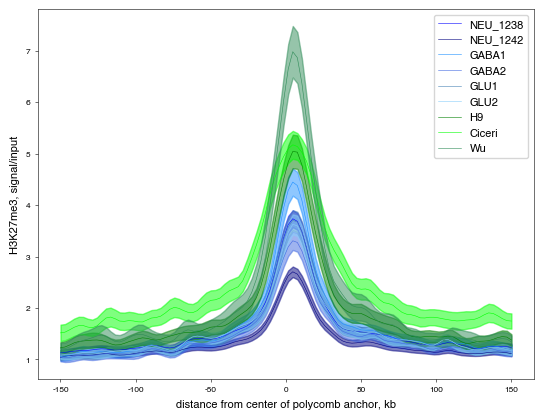

In [1065]:
labs=['NEU_1238','NEU_1242','GABA1','GABA2','GLU1','GLU2','H9','Ciceri','Wu']#'H1',
k=0
colo=['blue','navy','dodgerblue','royalblue','steelblue','lightskyblue','green','lime','seagreen']#'darkgreen',

for i in ['NEU_1238','NEU_1242','GABA1','GABA2','GLU1','GLU2',
          'CULT1','CULT3','CULT4']:
    dg=df[[0,1,2,i]]
        
    p=pylap_new(path_to_points,dg,30,chrs,5000,chrom_dict)

    p.dropna(inplace=True)
    plott(p,labs[k],30,colo[k],0.5,True)
    k+=1
plt.xticks(np.arange(0,61,10),np.arange(-30,31,10)*5)
plt.xlabel('distance from center of polycomb anchor, kb')
plt.ylabel('H3K27me3, signal/input')

plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/H3K27me3/H3K27me3_curves_all_data_no_H1.pdf')

Text(0, 0.5, 'H3K27me3, signal/input')

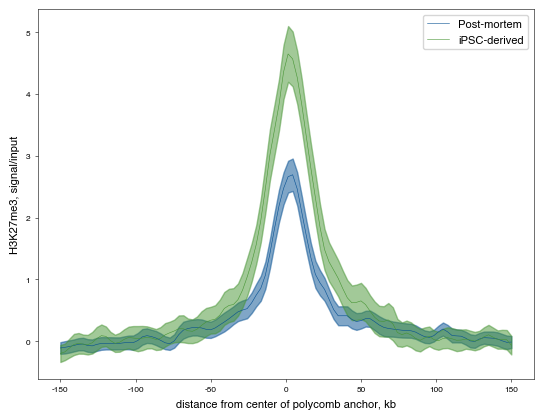

In [976]:
labs=['Post-mortem','iPSC-derived']
k=0
colo=[pm,ipsc]
#colo=['blue','dodgerblue','limegreen','green','forestgreen']
path_to_points='/media/anna/Samsung_T5/culture_vs_postmortem/polycomb_hand_made_centers_plus_one.bed'
for j in ['NEU_mean','CULT_mean']:
    dg=df[[0,1,2,j]]
        
    p=pylap_new(path_to_points,dg,30,chrs,5000,chrom_dict)
    for i in range(len(p)):
        p.loc[i]=p.loc[i]-p.loc[i][list(np.arange(0,10))+list(np.arange(51,61))].mean()
    if j=='NEU_mean':
        p_pm=p.copy()
    p.dropna(inplace=True)
    plott(p,labs[k],30,colo[k],0.5,True)
    k+=1
plt.xticks(np.arange(0,61,10),np.arange(-30,31,10)*5)
plt.xlabel('distance from center of polycomb anchor, kb')
plt.ylabel('H3K27me3, signal/input')
#plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/H3K27me3/H3K27me3_curves_mean_neun_Kozlenkov_cult_with_Ciceri_Wu_zero_centered.pdf')

In [977]:
p_cult=p

In [978]:
scipy.stats.wilcoxon(p_cult[30],p_pm[30])

WilcoxonResult(statistic=4104.0, pvalue=3.400441515009423e-16)

In [126]:
###################### BroadPeaks analysis ########################

In [115]:
pcb1=pcb[['chrom1','start1','end1']]
pcb2=pcb[['chrom2','start2','end2']]
pcb1.columns=[0,1,2]
pcb2.columns=[0,1,2]

pcb_loc=pd.concat([pcb1,pcb2])
pcb_loc.drop_duplicates([0,1,2],inplace=True)
pcb_loc_bed=pybedtools.BedTool.from_dataframe(pcb_loc)

In [148]:
peaks_path='/media/anna/Samsung_T5/culture_vs_postmortem/H3K27me3/broad_peaks/'

In [1059]:
peaks=[
 '1238_H3K27me3_DLPFC_NEUN_REP1_peaks.broadPeak',
 '1242_H3K27me3_DLPFC_NEUN_REP1_peaks.broadPeak',
 'H276_GABA_REP1_peaks.broadPeak',
 'H276_GLU_REP1_peaks.broadPeak',
 'H372_GABA_REP1_peaks.broadPeak',
 'H372_GLU_REP1_peaks.broadPeak',
 'H3K27me3_Neuron_Dong.broadPeak',
 'CnR_H3K27me3_D53_peaks.broadPeak',
 'H9_signal_REP1_peaks.broadPeak',
 'Wu_H3K27me3_REP1_peaks.broadPeak']


In [1060]:
names=[ '1238','1242','H276_GABA','H276_GLU',
 'H372_GABA','H372_GLU','Dong','CnR_D53','H9','Wu']
k=0
res_rat=[]
for i in peaks:
    tmp=pd.read_csv(peaks_path+i,sep='\t',header=None)
    tmp_bed=pybedtools.BedTool.from_dataframe(tmp[[0,1,2,7]])
    in_dots=tmp_bed.intersect(pcb_loc_bed,wa=True).to_dataframe()
    not_in_dots=tmp_bed.subtract(pcb_loc_bed,A=True).to_dataframe()
    ratio=np.nanmedian(in_dots.name)/np.nanmedian(not_in_dots.name)
    res_rat.append(ratio)
    k+=1

([<matplotlib.axis.XTick at 0x7feaaa41bac0>,
 [Text(0, 0, '1238'),
  Text(1, 0, '1242'),
  Text(2, 0, 'H276_GABA'),
  Text(3, 0, 'H276_GLU'),
  Text(4, 0, 'H372_GABA'),
  Text(5, 0, 'H372_GLU'),
  Text(6, 0, 'Dong'),
  Text(7, 0, 'CnR_D53'),
  Text(8, 0, 'H1'),
  Text(9, 0, 'H9'),
  Text(10, 0, 'Wu')])

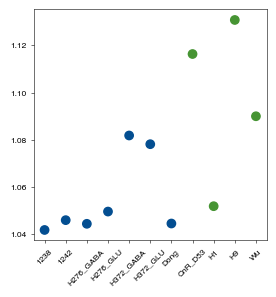

In [184]:
plt.figure(figsize=(3,3))
plt.scatter(np.arange(len(names)),res_rat,c=[pm,pm,pm,pm,pm,pm,pm,ipsc,ipsc,ipsc,ipsc])
plt.xticks(np.arange(len(names)),names,rotation=45)

In [1061]:
scipy.stats.mannwhitneyu(res_rat[0:7],res_rat[7:])

MannwhitneyuResult(statistic=0.0, pvalue=0.016666666666666666)

In [1062]:
res_rat

[1.0418902220921535,
 1.0460473511962285,
 1.0444989612154134,
 1.0496825203457363,
 1.081870750812888,
 1.078186530924535,
 1.0446230059606667,
 1.116345396168276,
 1.130748630746,
 1.0900114710869198]

In [1063]:
data_tmp=pd.DataFrame({'ratio':res_rat,'type':['Post-mortem']*7+['iPSC-derived']*3})

/tmp/ipykernel_37010/4097045027.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a=sns.boxplot(data=my_df, y='ratio',x='type',palette=pal1,
/tmp/ipykernel_37010/4097045027.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=my_df, y='ratio',x='type',legend=False,s=3,palette=pal1)


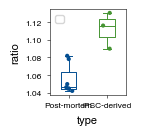

In [1064]:
my_df=data_tmp.copy()
ipsc='#469433'
pm='#034e91'
pal1=[pm,ipsc]
pal2=['#034e9180','#46943380']
pal3=['#034e9100','#46943300']

fig=plt.figure(figsize=(1.4,1.4))

pts=np.linspace(0,np.pi*2,24)
circ=np.c_[np.sin(pts)/2,-np.cos(pts)/2]
vert=np.r_[circ,circ[::-1]*.7]
open_circle=mpl.path.Path(vert)

a=sns.boxplot(data=my_df, y='ratio',x='type',palette=pal1,
          linewidth=0.7,fliersize=0.3,showfliers=False,fill=False,gap=0.5,legend=False)
        
sns.stripplot(data=my_df, y='ratio',x='type',legend=False,s=3,palette=pal1) 

plt.tight_layout()
plt.legend('')
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/within_outside_dots_ratio_of_medians_no_H1.pdf')


In [1026]:
data_tmp

,ratio,type
0,1.021086,Post-mortem
1,0.948694,Post-mortem
2,0.997337,Post-mortem
3,0.971386,Post-mortem
4,1.047952,Post-mortem
5,1.048862,Post-mortem
6,1.171818,Post-mortem
7,1.143937,iPSC-derived
8,1.305968,iPSC-derived
9,1.252866,iPSC-derived


In [1027]:
data_tmp['names']=[ '1238','1242','H276_GABA','H276_GLU',
 'H372_GABA','H372_GLU','Dong','CnR_D53','H1','H9','Wu']

In [1028]:
data_tmp.index=data_tmp.names

In [1029]:
data_tmp=data_tmp.loc[['CnR_D53','H276_GABA','H372_GABA','H276_GLU','H372_GLU','Wu','H1','H9','1238','1242']]

In [1036]:
data_tmp['frip']=frip

In [1037]:
data_tmp['nsc']=nsc

In [1038]:
data_tmp['rsc']=rsc

In [1033]:
frip={'CnR_D53':0.25,'H276_GABA':0.29,'H372_GABA':0.37,'H276_GLU':0.39,'H372_GLU':0.39,'Wu':0.15,'H1':0.05,'H9':0.15,'1238':0.1,'1242':0.04}

In [1034]:
nsc={'CnR_D53':1.1,'H276_GABA':1.19,'H372_GABA':1.15,'H276_GLU':1.24,'H372_GLU':1.19,'Wu':1.04,'H1':1,'H9':1.023,'1238':1.007,'1242':1.009}

In [1035]:
rsc={'CnR_D53':8.2,'H276_GABA':13.6,'H372_GABA':14.7,'H276_GLU':10.9,'H372_GLU':19.3,'Wu':1.1,'H1':0.45,'H9':0.97,'1238':0.15,'1242':0.15}

In [1039]:
data_tmp['cols']=[ipsc,pm,pm,pm,pm,ipsc,ipsc,ipsc,pm,pm]

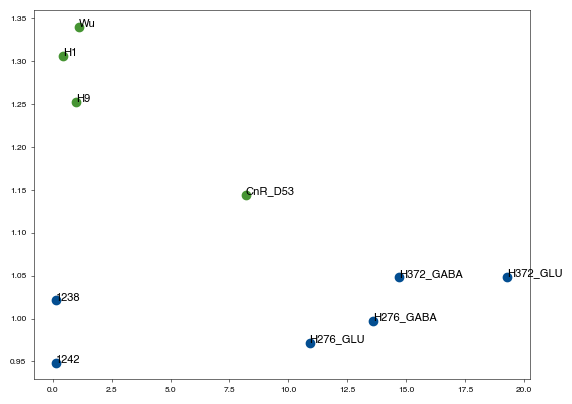

In [1049]:
for i, txt in enumerate(data_tmp.names):
    plt.text(data_tmp.iloc[i]['rsc'],data_tmp.iloc[i]['ratio'],txt) 
    plt.scatter(data_tmp.iloc[i]['rsc'],data_tmp.iloc[i]['ratio'],c=data_tmp.iloc[i]['cols'])
    
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/rsc_vs_means.pdf')

In [1046]:
data_tmp

,ratio,type,names,frip,nsc,rsc,cols
names,,,,,,,
CnR_D53,1.143937,iPSC-derived,CnR_D53,0.25,1.100,8.20,#469433
H276_GABA,0.997337,Post-mortem,H276_GABA,0.29,1.190,13.60,#034e91
H372_GABA,1.047952,Post-mortem,H372_GABA,0.37,1.150,14.70,#034e91
H276_GLU,0.971386,Post-mortem,H276_GLU,0.39,1.240,10.90,#034e91
H372_GLU,1.048862,Post-mortem,H372_GLU,0.39,1.190,19.30,#034e91
Wu,1.340274,iPSC-derived,Wu,0.15,1.040,1.10,#469433
H1,1.305968,iPSC-derived,H1,0.05,1.000,0.45,#469433
H9,1.252866,iPSC-derived,H9,0.15,1.023,0.97,#469433
1238,1.021086,Post-mortem,1238,0.10,1.007,0.15,#034e91


In [82]:
################################################################################

In [192]:
neu_broad1=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/H3K27me3/broad_peaks/H276_GLU_REP1_peaks.broadPeak',sep='\t',header=None)
neu_broad2=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/H3K27me3/broad_peaks/H372_GLU_REP1_peaks.broadPeak',sep='\t',header=None)
neu_broad3=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/H3K27me3/broad_peaks/H276_GABA_REP1_peaks.broadPeak',sep='\t',header=None)
neu_broad4=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/H3K27me3/broad_peaks/H372_GABA_REP1_peaks.broadPeak',sep='\t',header=None)


neu_broad=pd.concat([neu_broad1,neu_broad2,neu_broad3,neu_broad4])
neu_broad.sort_values([0,1,2],inplace=True)

neu_broad_bed=pybedtools.BedTool.from_dataframe(neu_broad)
neu_broad_bed=neu_broad_bed.merge()


In [193]:
a=pd.read_csv('/home/anna/anna_data/Autism/rnaseq.rizzardi2019.counts.GENCODE.autosomes_and_chrX.with_meta.tsv',sep='\t')
g=pd.read_csv('/home/anna/anna_data/Autism/GENCODE.v41.annotation.bed',sep='\t',header=None)
g[6]=g[1]
g.loc[g[5]=='-',6]=g[2]
gg=g.loc[g[3].isin(a['gene.id'])]
gg.sort_values([0,6],inplace=True)
gg.drop_duplicates([0,1],keep='first',inplace=True)
g_bed=pybedtools.BedTool.from_dataframe(gg[[0,6,6,3]])

/tmp/ipykernel_188758/1789143072.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gg.sort_values([0,6],inplace=True)
/tmp/ipykernel_188758/1789143072.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gg.drop_duplicates([0,1],keep='first',inplace=True)


In [194]:
fn=neu_broad_bed.to_dataframe()
ff=fn.copy()
ff_bed=pybedtools.BedTool.from_dataframe(ff.sort_values(['chrom','start']))
ff_bed=ff_bed.merge()
h3k27me3_in_dots_bed=ff_bed.intersect(pcb_loc_bed,wa =True)

In [195]:
cult_h3k27me3_bed=pybedtools.BedTool.from_dataframe(df[[0,1,2,'CULT_mean']])
neun_h3k27me3_bed=pybedtools.BedTool.from_dataframe(df[[0,1,2,'NEU_mean']])

ffc=h3k27me3_in_dots_bed.intersect(cult_h3k27me3_bed,wao=True).to_dataframe()
ffn=h3k27me3_in_dots_bed.intersect(neun_h3k27me3_bed,wao=True).to_dataframe()

ffc=ffc.loc[ffc.name!='.']
ffc=ffc[['chrom', 'start', 'end','thickStart','thickEnd']]
ffc.thickEnd=ffc.thickEnd/(ffc.end-ffc.start)
ffc.columns=['chrom', 'start', 'end','signal','ratio']
ffc.signal=ffc.signal.astype(float)
ffc['signal_norm']=ffc.signal*ffc.ratio
ffc=ffc.groupby(['chrom', 'start', 'end']).sum().reset_index()
ffc=ffc[['chrom','start','end','signal_norm']]

ffn=ffn.loc[ffn.name!='.']
ffn=ffn[['chrom', 'start', 'end','thickStart','thickEnd']]
ffn.thickEnd=ffn.thickEnd/(ffn.end-ffn.start)
ffn.columns=['chrom', 'start', 'end','signal','ratio']
ffn.signal=ffn.signal.astype(float)
ffn['signal_norm_neu']=ffn.signal*ffn.ratio
ffn=ffn.groupby(['chrom', 'start', 'end']).sum().reset_index()
ffn=ffn[['chrom','start','end','signal_norm_neu']]


h3k27me3_in_dots=ffn.copy()
h3k27me3_in_dots['signal_norm_cult']=ffc.signal_norm

In [196]:
h3k27me3_in_dots_bed=pybedtools.BedTool.from_dataframe(h3k27me3_in_dots)
h3k27me3_expr=h3k27me3_in_dots_bed.intersect(g_bed,wao=True).to_dataframe()


In [197]:
ipsc='#469433'
fet='#9c2725'
pm='#034e91'
npc='#e38519'
sc='#696969'


In [198]:
expr=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/rlog_protein_coding_cortex_all_blind_true.txt',sep='\t',index_col=0)

expr['pm']=np.nanmean(expr[['acc_rous', 'dlpfc_rous', 'riz']],axis=1)
expr['iPSCder']=np.nanmean(expr[['Li_iPSCder', 'Lu_iPSCder','PRJNA_iPSCder', 'Zaghi_iPSCder', 'Ciceri50_iPSCder']],axis=1)
expr['iPSC']=np.nanmean(expr[['Flamier_iPSC','Lu_iPSC']],axis=1)
expr['NPC']=np.nanmean(expr[['Topol_NPC', 'Lu_NPC']],axis=1)

expr=expr[['iPSC', 'NPC', 'iPSCder','pm']]

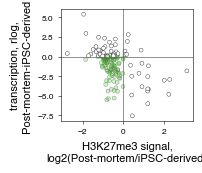

In [199]:
h3k27me3_expr=h3k27me3_expr.loc[h3k27me3_expr.strand!='.']

expr_pm=expr.pm
expr_cult=expr.iPSCder


h3k27me3_expr=h3k27me3_expr.loc[h3k27me3_expr.itemRgb.isin(expr_pm.index)]

h3k27me3_expr['neu_expr']=list(expr_pm.loc[h3k27me3_expr.itemRgb])
h3k27me3_expr['cult_expr']=list(expr_cult.loc[h3k27me3_expr.itemRgb])



h3k27me3_expr=h3k27me3_expr[['chrom', 'start', 'end', 'name', 'score', 'itemRgb', 'neu_expr', 'cult_expr']]

h3k27me3_expr.columns=['chrom', 'start', 'end', 'signal_in_neu', 'signal_in_cult', 'gene', 'neu_expr', 'cult_expr']

dd=pd.DataFrame({'x':np.log2(h3k27me3_expr.signal_in_cult/h3k27me3_expr.signal_in_neu),
                'y':h3k27me3_expr.cult_expr-h3k27me3_expr.neu_expr,
                'col':'white','edgecolor':'black'})


dd.loc[(dd.x>0)&(dd.y>0),'col']=ipsc+'33'

dd.loc[(dd.x>0)&(dd.y>0),'edgecolor']=ipsc


plt.figure(figsize=(2,1.8))
plt.scatter(np.log2(h3k27me3_expr.signal_in_neu/h3k27me3_expr.signal_in_cult),h3k27me3_expr.neu_expr-h3k27me3_expr.cult_expr,s=8,lw=0.25,facecolors=dd.col, edgecolors=dd.edgecolor)#,alpha=0.1)
plt.xlabel('H3K27me3 signal,\nlog2(Post-mortem/iPSC-derived)')
plt.ylabel('transcription, rlog,\nPost-mortem-iPSC-derived')
plt.axhline(0,linewidth=0.5)
plt.axvline(0,linewidth=0.5)
plt.tight_layout()
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/H3K27me3_expression_dif_union_GABA_GLU_for_neu_Wu_Ciceri_for_cult_new.pdf')

In [189]:
scipy.stats.chi2_contingency([[len(dd.loc[(dd.x<0)&(dd.y>0)]),len(dd.loc[(dd.x>0)&(dd.y>0)])],
                              [len(dd.loc[(dd.x<0)&(dd.y<0)]),len(dd.loc[(dd.x>0)&(dd.y<0)])]])

(0.22089432204382983,
 0.6383593331516065,
 1,
 array([[15.52147239, 94.47852761],
        [ 7.47852761, 45.52147239]]))

In [12]:
############################ ACC and DLPFC ################################

In [86]:
p1=pd.read_csv('/home/anna/Downloads/polyc_start1_lifted_to_hg19.bed',sep='\t',header=None)
p2=pd.read_csv('/home/anna/Downloads/polyc_start2_lifted_to_hg19.bed',sep='\t',header=None)

In [87]:
p1=p1.loc[p1[0].isin(c.chromnames)]
p2=p2.loc[p2[0].isin(c.chromnames)]

In [88]:
p1=p1.groupby([3]).min().reset_index()

In [90]:
p2=p2.groupby([3]).min().reset_index()

In [92]:
p1.index=p1[3]
p2.index=p2[3]

In [96]:
p=pd.concat([p1,p2],axis=1)

In [98]:
p.columns=np.arange(0,len(p.columns))

In [100]:
p=p[[1,2,6]]

In [102]:
p.columns=['chrom','start1','start2']

In [105]:
files=['Hu2021_NeuNplus.sampled_exact.mcool',
       'PM_NeuN_minus_inter_sample_HBCC2405_CMC_HBCC_414_204476188_5_20K.mcool']


names=['Hu','Rajarajan']

samples={}

poly=pcb.copy()
poly.start1=(poly.start1/20000).astype(int)
poly.start2=(poly.start2/20000).astype(int)
scores=np.zeros((25,25,len(poly)))
scores[:]=np.nan
c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/20000'%files[0])
l=0
for ch in np.unique(poly['chrom1']):
    tmp=poly.loc[poly['chrom1']==ch]
    m=norm(c,ch)
    for i in range(len(tmp)):
        x=tmp.iloc[i]['start1']
        y=tmp.iloc[i]['start2']
        scores[:,:,l]=m[x-10:x+15,y-10:y+15]
        l+=1
            
    samples[names[0]]=scores

poly=p.copy()
poly.start1=(poly.start1/20000).astype(int)
poly.start2=(poly.start2/20000).astype(int)
scores=np.zeros((25,25,len(poly)))
scores[:]=np.nan
c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/20000'%files[1])
l=0
for ch in np.unique(poly['chrom']):
    tmp=poly.loc[poly['chrom']==ch]
    m=norm(c,ch)
    for i in range(len(tmp)):
        x=tmp.iloc[i]['start1']
        y=tmp.iloc[i]['start2']
        scores[:,:,l]=m[x-10:x+15,y-10:y+15]
        l+=1
            
    samples[names[1]]=scores

    


/tmp/ipykernel_2167833/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_2167833/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))


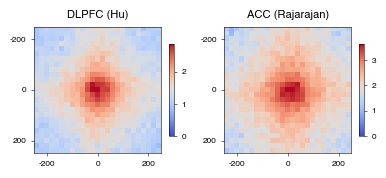

In [110]:


fig=plt.figure(figsize=(4.5,2))

fig.add_subplot(1,2,1)

x1=np.nanmean(samples[names[0]],axis=2)
plt.imshow(np.log2(x1),cmap='coolwarm',vmin=0)#,vmax=2.9)
plt.colorbar(shrink=0.6)
plt.xticks([2,12,22],[-200,0,200])
plt.yticks([2,12,22],[-200,0,200])
plt.title('DLPFC (Hu)')

fig.add_subplot(1,2,2)
x1=np.nanmean(samples[names[1]],axis=2)
plt.imshow(np.log2(x1),cmap='coolwarm',vmin=0)#,vmax=2.9)
plt.colorbar(shrink=0.6)
plt.xticks([2,12,22],[-200,0,200])
plt.yticks([2,12,22],[-200,0,200])
plt.title('ACC (Rajarajan)')

plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/polyc_average_heatmap_DLPFC_ACC.pdf')

In [107]:
######################## expression ##################

In [681]:
expr=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/rlog_protein_coding_cortex_all_blind_true.txt',sep='\t',index_col=0)

expr['pm']=np.nanmean(expr[['acc_rous', 'dlpfc_rous', 'riz']],axis=1)
expr['iPSCder']=np.nanmean(expr[['Li_iPSCder', 'Lu_iPSCder','PRJNA_iPSCder', 'Zaghi_iPSCder', 'Ciceri50_iPSCder']],axis=1)
expr['iPSC']=np.nanmean(expr[['Flamier_iPSC','Lu_iPSC']],axis=1)
expr['NPC']=np.nanmean(expr[['Topol_NPC', 'Lu_NPC']],axis=1)

expr=expr[['iPSC', 'NPC', 'iPSCder','pm']]

In [682]:

c1=pybedtools.BedTool.from_dataframe(pcb[['chrom1','start1','end1']])
c2=pybedtools.BedTool.from_dataframe(pcb[['chrom1','start2','end2']])

gene1=g_bed.intersect(c1)
gene1=gene1.intersect(neu_peak_bed).to_dataframe()

gene2=g_bed.intersect(c2)
gene2=gene2.intersect(neu_peak_bed).to_dataframe()

polyc_genes=pd.concat([gene1[['name']],gene2[['name']]])

/tmp/ipykernel_188758/603306035.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gg.sort_values([0,6],inplace=True)
/tmp/ipykernel_188758/603306035.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gg.drop_duplicates([0,1],keep='first',inplace=True)


In [683]:
polyc_genes.drop_duplicates(inplace=True)

In [684]:
ids=set(polyc_genes.name)&set(expr.index)

In [685]:
scipy.stats.wilcoxon(expr.loc[ids,'iPSCder'],expr.loc[ids,'pm'])

/tmp/ipykernel_188758/2403361258.py:1: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  scipy.stats.wilcoxon(expr.loc[ids,'iPSCder'],expr.loc[ids,'pm'])
/tmp/ipykernel_188758/2403361258.py:1: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  scipy.stats.wilcoxon(expr.loc[ids,'iPSCder'],expr.loc[ids,'pm'])


WilcoxonResult(statistic=5536.0, pvalue=4.1047444088778995e-12)

In [686]:
scipy.stats.wilcoxon(expr.loc[ids,'NPC'],expr.loc[ids,'pm'])

/tmp/ipykernel_188758/356174935.py:1: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  scipy.stats.wilcoxon(expr.loc[ids,'NPC'],expr.loc[ids,'pm'])
/tmp/ipykernel_188758/356174935.py:1: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  scipy.stats.wilcoxon(expr.loc[ids,'NPC'],expr.loc[ids,'pm'])


WilcoxonResult(statistic=3397.0, pvalue=3.199956347018983e-20)

/tmp/ipykernel_188758/1950631655.py:7: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  expr_avr=expr.loc[ids]#[['iPSC','NPC','iPSCder','PM']]
/tmp/ipykernel_188758/1950631655.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a=sns.boxplot(data=my_df, y='transcription, rlog',x='cell type',palette=pal,


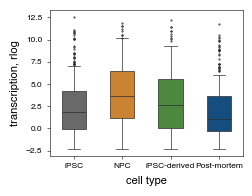

In [687]:
ipsc='#469433'
fet='#9c2725'
pm='#034e91'
npc='#e38519'
sc='#696969'

expr_avr=expr.loc[ids]
expr_avr.columns=['iPSC','NPC','iPSC-derived','Post-mortem']
my_df=pd.DataFrame()

y1=[]
l=len(expr_avr)
for i in expr_avr.columns:
    y1=y1+list(expr_avr[i])
y2=['iPSC']*l+['NPC']*l+['iPSC-derived']*l+['Post-mortem']*l

my_df['transcription, rlog']=y1
my_df['cell type']=y2

pal=[sc,npc,ipsc,pm]
plt.figure(figsize=(2.5,2))

a=sns.boxplot(data=my_df, y='transcription, rlog',x='cell type',palette=pal,
           linewidth=0.5,fliersize=0.5,whis=0.7,width=0.5)

x1, x2 = -0.25,0.25
plt.tight_layout()
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/expr_in_polyc_four_types_v2.pdf')


In [688]:
expr=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/rlog_protein_coding_cortex_all_blind_true.txt',sep='\t')

In [689]:
expr=expr[['riz','acc_rous', 'dlpfc_rous', 'Lu_iPSCder',
       'PRJNA_iPSCder','Ciceri50_iPSCder','Zaghi_iPSCder', 'Li_iPSCder']]

In [690]:
a=pd.read_csv('/home/anna/anna_data/Autism/rnaseq.rizzardi2019.counts.GENCODE.autosomes_and_chrX.with_meta.tsv',sep='\t')
a.index=a['gene.id']
pol=expr.loc[["ENSG00000100395","ENSG00000115289",'ENSG00000204227','ENSG00000168283','ENSG00000121481','ENSG00000106462','ENSG00000156374','ENSG00000074266']+list(a.loc[a['gene.name'].isin(['CBX2','CBX4','CBX6','CBX7','CBX8']),'gene.id'])]
pol['names']=a.loc[["ENSG00000100395","ENSG00000115289",'ENSG00000204227','ENSG00000168283','ENSG00000121481','ENSG00000106462','ENSG00000156374','ENSG00000074266']+list(a.loc[a['gene.name'].isin(['CBX2','CBX4','CBX6','CBX7','CBX8']),'gene.id']),'gene.name']

pol2=pol[pol.columns[0:(len(pol.columns)-1)]]
pol2.index=pol.names



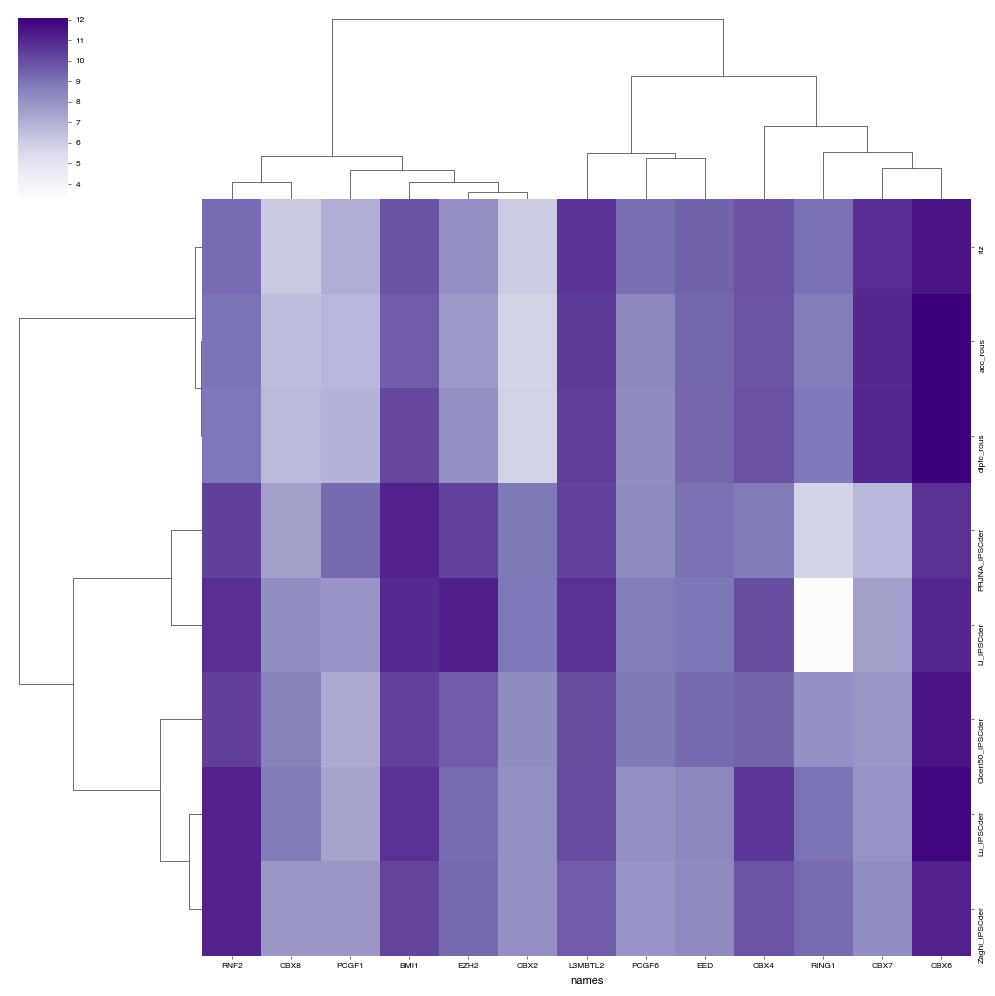

In [692]:

sns.clustermap(pol2.transpose(),metric='correlation',cmap="Purples")
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/polyc_subunits_in_cult_and_postmort_clustering_new.pdf')

In [1161]:
pcb_anchors=pybedtools.BedTool('/home/anna/anna_data/Autism/polycomb_dot_anchors.hand_made.bed')

In [1162]:
comp=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/compartments_table.csv')

In [1163]:
comp_bed=pybedtools.BedTool.from_dataframe(comp[['chrom','start','end','E1.iPSC-derived neurons','E1.Post-mortem neurons']])

In [1164]:
dd=comp_bed.intersect(pcb_anchors).to_dataframe()

In [1165]:
dd[dd=='.']=np.nan

In [1166]:
for c in dd.columns[3:]:
    dd[c]=dd[c].astype(float)

In [1167]:
dd.columns=['chrom','start','end','E1.iPSC-derived neurons','E1.Post-mortem neurons']#comp.columns

In [1168]:
dd.dropna(inplace=True)

In [1169]:
neu_peak=pd.read_csv('/home/anna/Downloads/H3K27me3_Neuron.broadPeak',sep=' ',header=None)

neu_peak_bed=pybedtools.BedTool.from_dataframe(neu_peak[[0,1,2,6]])

In [1170]:
dd_bed=pybedtools.BedTool.from_dataframe(dd)

In [1171]:
dd=dd_bed.intersect(neu_peak_bed,wa=True).to_dataframe()

In [1172]:
dd=dd.groupby(['chrom','start','end']).mean().reset_index()

In [1173]:
dd.columns=['chrom','start','end','E1.iPSC-derived neurons','E1.Post-mortem neurons']

In [1174]:
dd=dd.drop_duplicates(['chrom','start','end','E1.iPSC-derived neurons','E1.Post-mortem neurons'])

In [1175]:
ba=dd.loc[(dd['E1.iPSC-derived neurons']<-0.05)&(dd['E1.Post-mortem neurons']>0.05)]
ab=dd.loc[(dd['E1.iPSC-derived neurons']>0.05)&(dd['E1.Post-mortem neurons']<-0.05)]
aa=dd.loc[(dd['E1.iPSC-derived neurons']>0.05)&(dd['E1.Post-mortem neurons']>0.05)]
bb=dd.loc[(dd['E1.iPSC-derived neurons']<-0.05)&(dd['E1.Post-mortem neurons']<-0.05)]

In [1176]:
for i in [ba,ab,aa,bb]:
    print(len(i))

6
19
95
59


In [1177]:
summ=len(ba)+len(ab)+len(aa)+len(bb)

dat_test=[]
for i in [ba,aa,ab,bb]:
    dat_test.append(len(i)/summ)

In [1178]:
dat_test

[0.0335195530726257,
 0.5307262569832403,
 0.10614525139664804,
 0.329608938547486]

In [1179]:
trans_ids=set(ba.index)|set(ab.index)|set(aa.index)|set(bb.index)

In [1180]:
dd_rest=dd.loc[~dd.index.isin(trans_ids)]

In [1181]:
len(dd_rest)/len(dd)

0.16355140186915887

In [1182]:
dd_bed=pybedtools.BedTool.from_dataframe(dd)


In [1183]:
expr=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/rlog_protein_coding_cortex_all_blind_true.txt',sep='\t',index_col=0)

expr['pm']=np.nanmean(expr[['acc_rous', 'dlpfc_rous', 'riz']],axis=1)
expr['iPSCder']=np.nanmean(expr[['Li_iPSCder', 'Lu_iPSCder','PRJNA_iPSCder', 'Zaghi_iPSCder', 'Ciceri50_iPSCder']],axis=1)
expr['iPSC']=np.nanmean(expr[['Flamier_iPSC','Lu_iPSC']],axis=1)
expr['NPC']=np.nanmean(expr[['Topol_NPC', 'Lu_NPC']],axis=1)

expr=expr[['iPSC', 'NPC', 'iPSCder','pm']]
g=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/genes_hg38_ens_ids.txt',sep='\t',header=None)
g_bed=pybedtools.BedTool.from_dataframe(g[[0,6,6,3]])

d=dd_bed.intersect(g_bed,wao=True).to_dataframe()

d=d[['chrom', 'start', 'end', 'name', 'score', 'itemRgb']]

d.columns=['chrom','start','end','E1.iPSC-derived neurons','E1.Post-mortem neurons','id']

In [1184]:
d=d.loc[d.id!='.']

In [1185]:
expr=expr.loc[expr.index.isin(d.id)]

In [1186]:
d=d.loc[d.id.isin(expr.index)]

In [1187]:
data=expr.loc[list(d['id'])][['iPSCder','pm']].copy()


In [1188]:
ba=d.loc[(d['E1.iPSC-derived neurons']<-0.05)&(d['E1.Post-mortem neurons']>0.05),'id']
ab=d.loc[(d['E1.iPSC-derived neurons']>0.05)&(d['E1.Post-mortem neurons']<-0.05),'id']
aa=d.loc[(d['E1.iPSC-derived neurons']>0.05)&(d['E1.Post-mortem neurons']>0.05),'id']
bb=d.loc[(d['E1.iPSC-derived neurons']<-0.05)&(d['E1.Post-mortem neurons']<-0.05),'id']

In [1189]:
data['comp']='AA'
data.loc[ab,'comp']='AB'
data.loc[ba,'comp']='BA'
data.loc[bb,'comp']='BB'

In [1190]:
data1=data[['iPSCder','comp']]
data2=data[['pm','comp']]
data1['type']='iPSC-derived'
data2['type']='post-mortem'
data1.columns=[0,1,2]
data2.columns=[0,1,2]
data=pd.concat([data1,data2],axis=0)

In [1191]:
data.columns=['trasncription, rlog','compartment transition','type']

In [1193]:
a=pd.read_csv('/home/anna/anna_data/Autism/rnaseq.rizzardi2019.counts.GENCODE.autosomes_and_chrX.with_meta.tsv',sep='\t')

In [1194]:
nn=a['gene.name'].str.split('HOX',expand=True)

In [1195]:
gene_ids=a.loc[nn.loc[nn[0]==''].index,'gene.id']

In [1196]:
data_tpm=data.copy()

In [1198]:
data_tpm['col']='#46943380'
data_tpm.loc[data_tpm.type=='post-mortem','col']='#034e9180'

In [1199]:
data_tpm['fill']=data_tpm.col

In [1200]:
g_id=set(gene_ids)&set(data.index)

In [1201]:
data_tpm.loc[g_id,'fill']='00FFFFFF'

/tmp/ipykernel_188758/1858667803.py:1: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  data_tpm.loc[g_id,'fill']='00FFFFFF'


/tmp/ipykernel_188758/1336996387.py:26: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(data=my_df, y='trasncription, rlog',x='compartment transition',hue='type',legend=False,dodge=True,order=['BA','AA','AB','BB'],s=1.2,palette=pal)


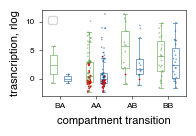

In [1202]:
my_df=data_tpm.copy()
ipsc='#469433'
fet='#9c2725'
pm='#034e91'
npc='dimgrey'

pal=['#E50000']
pal2=['#46943380','#034e9180']
pal3=['#46943300','#034e9100']
fig=plt.figure(figsize=(2,1.4))

pts=np.linspace(0,np.pi*2,24)
circ=np.c_[np.sin(pts)/2,-np.cos(pts)/2]
vert=np.r_[circ,circ[::-1]*.7]
open_circle=mpl.path.Path(vert)

a=sns.boxplot(data=my_df, y='trasncription, rlog',x='compartment transition',hue='type',dodge=True,order=['BA','AA','AB','BB'],palette=pal2,
          linewidth=0.7,fliersize=0.3,showfliers=False,fill=False,gap=0.5,legend=False)
        
my_df=data_tpm.loc[data_tpm.index.isin(g_id)].copy()
sns.stripplot(data=my_df, y='trasncription, rlog',x='compartment transition',hue='type',legend=False,dodge=True,order=['BA','AA','AB','BB'],s=1.2,palette=pal) 

my_df=data_tpm.loc[~data_tpm.index.isin(g_id)].copy()
sns.stripplot(data=my_df, y='trasncription, rlog',x='compartment transition',hue='type',legend=False,dodge=True,order=['BA','AA','AB','BB'],s=1.2,palette=pal2) 

plt.tight_layout()
plt.legend('')
#plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/expr_transitions_pcb_comp_neu_peak_h3k27me3_more_strong_compartments_rlog.pdf')


In [1203]:
x1=data_tpm.loc[(data_tpm['compartment transition']=='AB')&(data_tpm['type']=='iPSC-derived'),'trasncription, rlog']
x2=data_tpm.loc[(data_tpm['compartment transition']=='AB')&(data_tpm['type']=='post-mortem'),'trasncription, rlog']

In [1204]:
scipy.stats.wilcoxon(x1,x2)

WilcoxonResult(statistic=0.0, pvalue=0.000244140625)

In [1205]:
x1=data_tpm.loc[(data_tpm['compartment transition']=='AA')&(data_tpm['type']=='iPSC-derived'),'trasncription, rlog']
x2=data_tpm.loc[(data_tpm['compartment transition']=='AA')&(data_tpm['type']=='post-mortem'),'trasncription, rlog']

scipy.stats.wilcoxon(x1,x2)

WilcoxonResult(statistic=697.0, pvalue=9.556465428310487e-06)

In [1206]:
x1=data_tpm.loc[(data_tpm['compartment transition']=='BB')&(data_tpm['type']=='iPSC-derived'),'trasncription, rlog']
x2=data_tpm.loc[(data_tpm['compartment transition']=='BB')&(data_tpm['type']=='post-mortem'),'trasncription, rlog']

scipy.stats.wilcoxon(x1,x2)

WilcoxonResult(statistic=59.0, pvalue=0.01486515998840332)

In [1207]:
x1=data_tpm.loc[(data_tpm.index.isin(g_id))&(data_tpm['type']=='iPSC-derived')&(data_tpm['compartment transition']=='AA'),'trasncription, rlog']
x2=data_tpm.loc[(data_tpm.index.isin(g_id))&(data_tpm['type']=='post-mortem')&(data_tpm['compartment transition']=='AA'),'trasncription, rlog']

In [1209]:
scipy.stats.wilcoxon(x1,x2)

WilcoxonResult(statistic=103.0, pvalue=0.0003021703561574853)

In [1211]:
x1=data_tpm.loc[(~data_tpm.index.isin(g_id))&(data_tpm['type']=='iPSC-derived')&(data_tpm['compartment transition']=='AA'),'trasncription, rlog']
x2=data_tpm.loc[(~data_tpm.index.isin(g_id))&(data_tpm['type']=='post-mortem')&(data_tpm['compartment transition']=='AA'),'trasncription, rlog']

In [1212]:
scipy.stats.wilcoxon(x1,x2)

WilcoxonResult(statistic=218.0, pvalue=0.0012265058574692043)

In [748]:
number_of_genes=data_tpm.loc[data_tpm.type=='post-mortem','compartment transition'].value_counts()

In [750]:
number_of_genes

AA    81
BB    23
AB    13
BA     2
Name: compartment transition, dtype: int64

In [751]:
ba=dd.loc[(dd['E1.iPSC-derived neurons']<-0.05)&(dd['E1.Post-mortem neurons']>0.05)]
ab=dd.loc[(dd['E1.iPSC-derived neurons']>0.05)&(dd['E1.Post-mortem neurons']<-0.05)]
aa=dd.loc[(dd['E1.iPSC-derived neurons']>0.05)&(dd['E1.Post-mortem neurons']>0.05)]
bb=dd.loc[(dd['E1.iPSC-derived neurons']<-0.05)&(dd['E1.Post-mortem neurons']<-0.05)]

In [752]:
gene_dens=pd.DataFrame(number_of_genes)

In [753]:
gene_dens['bin_numb']=[len(aa),len(bb),len(ab),len(ba)]

In [754]:
gene_dens['density']=gene_dens['compartment transition']/gene_dens.bin_numb

In [755]:
gene_dens_by_tss=gene_dens.copy()

In [756]:
gene_dens_by_tss

,compartment transition,bin_numb,density
AA,81,95,0.852632
BB,23,59,0.389831
AB,13,19,0.684211
BA,2,6,0.333333


In [954]:
x=data_tpm.loc[(data_tpm['compartment transition']=='AB')&(data_tpm.type=='post-mortem')]

In [988]:
tmp=data_tpm.loc[(data_tpm['compartment transition']=='AA')&(data_tpm.type=='post-mortem')]
samp=[]
used=[]
for i in x.index:
    expr_tmp=x.loc[i]['trasncription, rlog']
    ids=tmp.loc[(tmp['trasncription, rlog']>expr_tmp-0.7)&(tmp['trasncription, rlog']<expr_tmp+0.7)].index
    ids=list(set(ids)-set(used))
    if len(ids)>1:
        ids=np.random.choice(ids)
        
    else:
        ids=ids[0]
    samp.append(ids)
    used.append(ids)

In [1007]:
y_backup_choice=y['trasncription, rlog']

{'whiskers': [<matplotlib.lines.Line2D at 0x7fe5a446e610>,
 'caps': [<matplotlib.lines.Line2D at 0x7fe5a446ea30>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fe5a446e370>,
 'medians': [<matplotlib.lines.Line2D at 0x7fe5a446ef70>,
 'fliers': [<matplotlib.lines.Line2D at 0x7fe5a445e250>,
 'means': []}

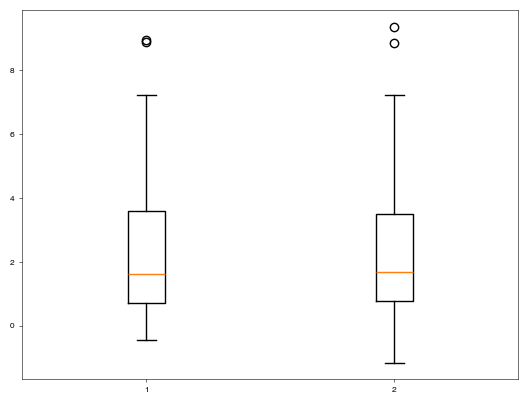

In [990]:
y=data_tpm.loc[data_tpm.index.isin(samp)&(data_tpm.type=='post-mortem')]

plt.boxplot([y['trasncription, rlog'],x['trasncription, rlog']])

In [991]:
scipy.stats.wilcoxon(y['trasncription, rlog'],x['trasncription, rlog'])

WilcoxonResult(statistic=40.0, pvalue=0.7353515625)

In [1002]:
tmp=data_tpm.loc[(data_tpm['compartment transition']=='BB')&(data_tpm.type=='post-mortem')]
samp=[]
used=[]
for i in x.index:
    expr_tmp=x.loc[i]['trasncription, rlog']
    ids=tmp.loc[(tmp['trasncription, rlog']>expr_tmp-0.7)&(tmp['trasncription, rlog']<expr_tmp+0.7)].index
    ids=list(set(ids)-set(used))
    if len(ids)>1:
        ids=np.random.choice(ids)
        
    else:
        ids=ids[0]
    samp.append(ids)
    used.append(ids)

{'whiskers': [<matplotlib.lines.Line2D at 0x7fe56d6e0940>,
 'caps': [<matplotlib.lines.Line2D at 0x7fe56d6e0e80>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fe56d6e06a0>,
 'medians': [<matplotlib.lines.Line2D at 0x7fe56d6fa400>,
 'fliers': [<matplotlib.lines.Line2D at 0x7fe56d6fa6a0>,
 'means': []}

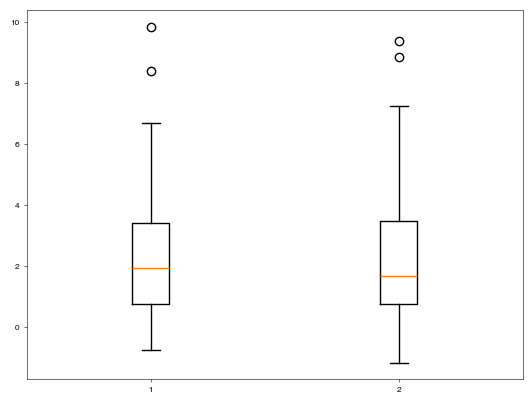

In [1003]:
z=data_tpm.loc[data_tpm.index.isin(samp)&(data_tpm.type=='post-mortem')]
plt.boxplot([z['trasncription, rlog'],x['trasncription, rlog']])

In [1004]:
scipy.stats.wilcoxon(z['trasncription, rlog'],x['trasncription, rlog'])

WilcoxonResult(statistic=44.0, pvalue=0.946044921875)

In [1006]:
z_backup_choice=z['trasncription, rlog']

In [1008]:
data_tpm_samp=data_tpm.loc[data.index.isin(set(z.index)|set(y.index)|set(x.index))]

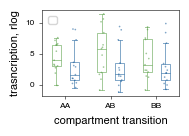

In [1012]:
my_df=data_tpm_samp.copy()
ipsc='#469433'
fet='#9c2725'
pm='#034e91'
npc='dimgrey'

pal=['#E50000']
pal2=['#46943380','#034e9180']
pal3=['#46943300','#034e9100']
fig=plt.figure(figsize=(2,1.4))

pts=np.linspace(0,np.pi*2,24)
circ=np.c_[np.sin(pts)/2,-np.cos(pts)/2]
vert=np.r_[circ,circ[::-1]*.7]
open_circle=mpl.path.Path(vert)

a=sns.boxplot(data=my_df, y='trasncription, rlog',x='compartment transition',hue='type',dodge=True,order=['AA','AB','BB'],palette=pal2,
          linewidth=0.7,fliersize=0.3,showfliers=False,fill=False,gap=0.5,legend=False)
plt.tight_layout()
plt.legend('')

sns.stripplot(data=my_df, y='trasncription, rlog',x='compartment transition',hue='type',legend=False,dodge=True,order=['AA','AB','BB'],s=1.2,palette=pal2) 

plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/expr_transitions_pcb_comp_neu_peak_h3k27me3_more_strong_compartments_rlog_random_sample.pdf')


In [1213]:
x1=data_tpm_samp.loc[(data_tpm_samp['compartment transition']=='AA')&(data_tpm_samp['type']=='iPSC-derived'),'trasncription, rlog']
x2=data_tpm_samp.loc[(data_tpm_samp['compartment transition']=='AA')&(data_tpm_samp['type']=='post-mortem'),'trasncription, rlog']

scipy.stats.wilcoxon(x1,x2)



WilcoxonResult(statistic=18.0, pvalue=0.057373046875)

In [1214]:
x1=data_tpm_samp.loc[(data_tpm_samp['compartment transition']=='BB')&(data_tpm_samp['type']=='iPSC-derived'),'trasncription, rlog']
x2=data_tpm_samp.loc[(data_tpm_samp['compartment transition']=='BB')&(data_tpm_samp['type']=='post-mortem'),'trasncription, rlog']

scipy.stats.wilcoxon(x1,x2)

WilcoxonResult(statistic=9.0, pvalue=0.008056640625)

In [1215]:
x1=data_tpm_samp.loc[(data_tpm_samp['compartment transition']=='AB')&(data_tpm_samp['type']=='iPSC-derived'),'trasncription, rlog']
x2=data_tpm_samp.loc[(data_tpm_samp['compartment transition']=='AB')&(data_tpm_samp['type']=='post-mortem'),'trasncription, rlog']

scipy.stats.wilcoxon(x1,x2)

WilcoxonResult(statistic=0.0, pvalue=0.000244140625)

In [127]:
a.loc[a['gene.id'].isin(x1.index)][['gene.id']].to_csv('/media/anna/Samsung_T5/culture_vs_postmortem/genes_from_AB_transcition.txt',sep='\t',header=None,index=None)

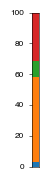

In [957]:
fig, ax = plt.subplots(figsize=(0.1,2))
bottom = np.zeros(4)

for c in dat:
    p = ax.bar([1], c*100, width=0.1,label=c, bottom=bottom)
    bottom += c*100
plt.xticks([])
plt.ylim(0,100)
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/comp_transitions_pcb_not_only_genes_strong_threshold_0.05.pdf')

In [349]:
############### EXPR in polyc and outside ############

In [1216]:
expr=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/rlog_protein_coding_cortex_all_blind_true.txt',sep='\t',index_col=0)
expr['pm']=np.nanmean(expr[['riz','acc_rous', 'dlpfc_rous',]],axis=1)
expr['iPSCder']=np.nanmean(expr[['Li_iPSCder', 'Lu_iPSCder','PRJNA_iPSCder', 'Zaghi_iPSCder', 'Ciceri50_iPSCder']],axis=1)
expr['iPSC']=np.nanmean(expr[['Flamier_iPSC','Lu_iPSC']],axis=1)
expr['NPC']=np.nanmean(expr[['Topol_NPC', 'Lu_NPC']],axis=1)

expr=expr[['iPSC', 'NPC', 'iPSCder','pm']]

In [1217]:
g=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/genes_hg38_ens_ids.txt',sep='\t',header=None)
g_bed=pybedtools.BedTool.from_dataframe(g[[0,6,6,3]])
g_in_peaks_bed=g_bed.intersect(neu_peak_bed)
gene_in_polyc=g_in_peaks_bed.intersect(pcb_anchors).to_dataframe()

In [1218]:
ids=set(expr.index)&set(gene_in_polyc.name)

In [1219]:
gene_in_polyc=gene_in_polyc.loc[gene_in_polyc.name.isin(ids)]

In [1220]:
iPSCder_polyc=expr.loc[gene_in_polyc.name][['iPSCder']]
iPSCder_polyc['type1']='iPSC-derived'
iPSCder_polyc['type2']='in PcG anchors'
pm_polyc=expr.loc[gene_in_polyc.name][['pm']]
pm_polyc['type1']='Post-mortem'
pm_polyc['type2']='in PcG anchors'

In [1221]:
iPSCder_out_polyc=expr.loc[~expr.index.isin(gene_in_polyc.name)][['iPSCder']]
iPSCder_out_polyc['type1']='iPSC-derived'
iPSCder_out_polyc['type2']='out of PcG anchors'
pm_out_polyc=expr.loc[~expr.index.isin(gene_in_polyc.name)][['pm']]
pm_out_polyc['type1']='Post-mortem'
pm_out_polyc['type2']='out of PcG anchors'

In [1222]:
iPSCder_out_polyc.columns=['trasncription, rlog','type1','type2']
pm_out_polyc.columns=['trasncription, rlog','type1','type2']
iPSCder_polyc.columns=['trasncription, rlog','type1','type2']
pm_polyc.columns=['trasncription, rlog','type1','type2']

In [1223]:
scipy.stats.mannwhitneyu(iPSCder_polyc['trasncription, rlog'],iPSCder_out_polyc['trasncription, rlog'])

MannwhitneyuResult(statistic=460585.0, pvalue=8.278418685709823e-27)

/tmp/ipykernel_188758/3972915092.py:6: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.boxplot(data=my_df,x="type2", y="trasncription, rlog",hue='type1',palette=pal, linewidth=0.5,fliersize=0.5,whis=0.7,width=0.6)


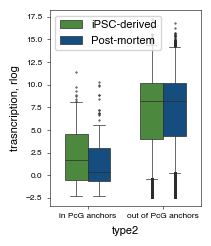

In [1032]:
plt.figure(figsize=(2.15,2.5))
my_df=pd.concat([iPSCder_polyc,pm_polyc,iPSCder_out_polyc,pm_out_polyc])

pal=['#46943380','#034e9180','#46943300','#034e9100']

sns.boxplot(data=my_df,x="type2", y="trasncription, rlog",hue='type1',palette=pal, linewidth=0.5,fliersize=0.5,whis=0.7,width=0.6)
plt.tight_layout()
#plt.ylim(-0.5,4.5)
plt.legend(loc='upper left')
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/expr_in_pcb_and_out_new.pdf')



In [97]:
pcb=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/polycomb_dot_anchors.hand_made.filt_by_fithic.bedpe',sep='\t')

In [878]:
pcb1=pcb[['chrom1','start1','end1']]
pcb1['id']=pcb1.index
pcb1_bed=pybedtools.BedTool.from_dataframe(pcb1)

pcb2=pcb[['chrom2','start2','end2']]
pcb2['id']=pcb2.index
pcb2_bed=pybedtools.BedTool.from_dataframe(pcb2)

df1=pcb1_bed.intersect(comp_bed,wao=True).to_dataframe()
df2=pcb2_bed.intersect(comp_bed,wao=True).to_dataframe()


/tmp/ipykernel_37010/3348617366.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pcb1['id']=pcb1.index
/tmp/ipykernel_37010/3348617366.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pcb2['id']=pcb2.index


In [879]:
df1=df1.groupby(['chrom','start','end','name']).max().reset_index()
df2=df2.groupby(['chrom','start','end','name']).max().reset_index()

In [880]:
df1=df1.loc[df1.thickEnd!='.']
df2=df2.loc[df2.thickEnd!='.']

In [881]:
df1.thickEnd=df1.thickEnd.astype(float)
df2.thickEnd=df2.thickEnd.astype(float)
df1.itemRgb=df1.itemRgb.astype(float)
df2.itemRgb=df2.itemRgb.astype(float)

In [882]:
pcb_comp=pcb.copy()


In [885]:
pcb_comp['iPSCder1_PC1']=np.nan
pcb_comp['pm1_PC1']=np.nan
pcb_comp['iPSCder2_PC1']=np.nan
pcb_comp['pm2_PC1']=np.nan
pcb_comp.loc[df1.name,'iPSCder1_PC1']=list(df1.thickEnd)
pcb_comp.loc[df1.name,'pm1_PC1']=list(df1.itemRgb)
pcb_comp.loc[df2.name,'iPSCder2_PC1']=list(df2.thickEnd)
pcb_comp.loc[df2.name,'pm2_PC1']=list(df2.itemRgb)


In [887]:
aa=pcb_comp.loc[(pcb_comp.iPSCder1_PC1>0.05)&(pcb_comp.pm1_PC1>0.05)&(pcb_comp.iPSCder2_PC1>0.05)&(pcb_comp.pm2_PC1>0.05)]

bb=pcb_comp.loc[(pcb_comp.iPSCder1_PC1<-0.05)&(pcb_comp.pm1_PC1<-0.05)&(pcb_comp.iPSCder2_PC1<-0.05)&(pcb_comp.pm2_PC1<-0.05)]

ab=pcb_comp.loc[(pcb_comp.iPSCder1_PC1>0.05)&(pcb_comp.pm1_PC1<-0.05)&(pcb_comp.iPSCder2_PC1>0.05)&(pcb_comp.pm2_PC1<-0.05)]

ba=pcb_comp.loc[(pcb_comp.iPSCder1_PC1<-0.05)&(pcb_comp.pm1_PC1>0.05)&(pcb_comp.iPSCder2_PC1<-0.05)&(pcb_comp.pm2_PC1>0.05)]

In [888]:
for i in [aa,bb,ab,ba]:
    print(len(i))

322
114
8
1


In [889]:
files=[
    'Ballerino2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Li2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Rahman2023_iPSC_NeuNplus_CRISPRi_Scrambled_A_DpnII-HinfI.sampled_exact.mcool',
 'Wu2021_iPSC_NeuNplus.sampled_exact.mcool',
 'Zaghi2023_iPSC_NeuNplus.sampled_exact.mcool',
 'PsychENCODE_iPSC_NeuNplus.sampled_exact.mcool',
 'Lagarkova_culture_iPSC_NeuNplus.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Heffel_infant.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',       
 'Heffel_adult.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Hu2021_NeuNplus.sampled_exact.mcool',
 'Pletenev2024_NeuNplus.sampled_exact.mcool',
 'Rahman2023_NeuNplus.sampled_exact.mcool',
 'Tian2023_NeuNplus.EN_IN.29_42_58_years.2000_cells.sampled_exact.mcool']


names=['Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag','Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']

k=0
samples_ab={}
poly=ab.copy()
poly.start1=(poly.start1/20000).astype(int)
poly.start2=(poly.start2/20000).astype(int)

for f in files:
    scores=np.zeros((25,25,len(poly)))
    scores[:]=np.nan
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/20000'%f)
    l=0
    for ch in np.unique(poly['chrom1']):
        tmp=poly.loc[poly['chrom1']==ch]
        m=norm(c,ch)
        for i in range(len(tmp)):
            x=tmp.iloc[i]['start1']
            y=tmp.iloc[i]['start2']
            scores[:,:,l]=m[x-10:x+15,y-10:y+15]
            l+=1
            
    samples_ab[names[k]]=scores
    k+=1

k=0
samples_aa={}
poly=aa.copy()
poly.start1=(poly.start1/20000).astype(int)
poly.start2=(poly.start2/20000).astype(int)

for f in files:
    scores=np.zeros((25,25,len(poly)))
    scores[:]=np.nan
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/20000'%f)
    l=0
    for ch in np.unique(poly['chrom1']):
        tmp=poly.loc[poly['chrom1']==ch]
        m=norm(c,ch)
        for i in range(len(tmp)):
            x=tmp.iloc[i]['start1']
            y=tmp.iloc[i]['start2']
            scores[:,:,l]=m[x-10:x+15,y-10:y+15]
            l+=1
            
    samples_aa[names[k]]=scores
    k+=1

    
k=0
samples_bb={}
poly=bb.copy()
poly.start1=(poly.start1/20000).astype(int)
poly.start2=(poly.start2/20000).astype(int)

for f in files:
    scores=np.zeros((25,25,len(poly)))
    scores[:]=np.nan
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/20000'%f)
    l=0
    for ch in np.unique(poly['chrom1']):
        tmp=poly.loc[poly['chrom1']==ch]
        m=norm(c,ch)
        for i in range(len(tmp)):
            x=tmp.iloc[i]['start1']
            y=tmp.iloc[i]['start2']
            scores[:,:,l]=m[x-10:x+15,y-10:y+15]
            l+=1
            
    samples_bb[names[k]]=scores
    k+=1

    
    
k=0
samples_ba={}
poly=ba.copy()
poly.start1=(poly.start1/20000).astype(int)
poly.start2=(poly.start2/20000).astype(int)

for f in files:
    scores=np.zeros((25,25,len(poly)))
    scores[:]=np.nan
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/20000'%f)
    l=0
    for ch in np.unique(poly['chrom1']):
        tmp=poly.loc[poly['chrom1']==ch]
        m=norm(c,ch)
        for i in range(len(tmp)):
            x=tmp.iloc[i]['start1']
            y=tmp.iloc[i]['start2']
            scores[:,:,l]=m[x-10:x+15,y-10:y+15]
            l+=1
            
    samples_ba[names[k]]=scores
    k+=1





/tmp/ipykernel_37010/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_37010/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_37010/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_37010/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_37010/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_37010/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_37010/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_37010/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_37010/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_37010/337638316.py:5: RuntimeWa

/tmp/ipykernel_37010/704532271.py:17: RuntimeWarning: Mean of empty slice
  x1.append(np.nanmean(samples_ba[f],axis=2))
/tmp/ipykernel_37010/704532271.py:21: RuntimeWarning: Mean of empty slice
  x3=np.nanmean(ba_pm,axis=2)
/tmp/ipykernel_37010/704532271.py:31: RuntimeWarning: divide by zero encountered in log2
  plt.imshow(np.log2(x2),cmap='coolwarm',vmin=-2.7,vmax=2.7)#,vmin=-0.3,vmax=2.5)#)#-np.log2(iPSCder)
/tmp/ipykernel_37010/704532271.py:17: RuntimeWarning: Mean of empty slice
  x1.append(np.nanmean(samples_ba[f],axis=2))
/tmp/ipykernel_37010/704532271.py:21: RuntimeWarning: Mean of empty slice
  x3=np.nanmean(ba_pm,axis=2)
/tmp/ipykernel_37010/704532271.py:31: RuntimeWarning: divide by zero encountered in log2
  plt.imshow(np.log2(x2),cmap='coolwarm',vmin=-2.7,vmax=2.7)#,vmin=-0.3,vmax=2.5)#)#-np.log2(iPSCder)
/tmp/ipykernel_37010/704532271.py:52: RuntimeWarning: Mean of empty slice
  x3=np.nanmean(aa_pm,axis=2)
/tmp/ipykernel_37010/704532271.py:82: RuntimeWarning: Mean of empt

0.19822107268596875
0.9561949274848028
0.3685961111069984
1.2915449189648256
-0.0005335626482471273
1.1710858619188254
0.31085346283815957
1.0778867420589222


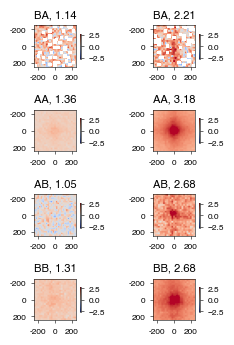

In [929]:
f3=['Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag']
f5=['Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']
k=1


fig=plt.figure(figsize=(2.5,3.5))

ba_pm=np.zeros((25,25,1))
ba_pm[:]=np.nan

for clas in [f3,f5]:
    fig.add_subplot(4,2,k)
    x1=[]
    for f in clas:
        x1.append(np.nanmean(samples_ba[f],axis=2))
        if clas==f5:
            aa_pm=np.dstack([ba_pm,samples_ba[f]])
    x2=np.nanmean(x1,axis=0)  
    tt=x2.copy()

    tt[9:16,9:16]=np.nan
    back=np.nanmean(tt)
    
    print(np.log2(np.mean(x2[10:15,10:15].flatten())/back))

    plt.imshow(np.log2(x2),cmap='coolwarm',vmin=-2.7,vmax=2.7)#
    plt.colorbar(shrink=0.6)
    plt.xticks([2,12,22],[-200,0,200])
    plt.yticks([2,12,22],[-200,0,200])
    plt.title('BA, %s'%(str(np.round(u,2))))
    k+=1


aa_pm=np.zeros((25,25,1))
aa_pm[:]=np.nan

for clas in [f3,f5]:
    fig.add_subplot(4,2,k)
    x1=[]
     for f in clas:
        x1.append(np.nanmean(samples_aa[f],axis=2))
        if clas==f5:
            aa_pm=np.dstack([aa_pm,samples_aa[f]])
    x2=np.nanmean(x1,axis=0)  
    tt=x2.copy()

    tt[9:16,9:16]=np.nan
    back=np.nanmean(tt)
    
    print(np.log2(np.mean(x2[10:15,10:15].flatten())/back))

    plt.imshow(np.log2(x2),cmap='coolwarm',vmin=-2.7,vmax=2.7)#,vmin=-0.3,vmax=2.5)#)#-np.log2(iPSCder)
    plt.colorbar(shrink=0.6)
    plt.xticks([2,12,22],[-200,0,200])
    plt.yticks([2,12,22],[-200,0,200])
    plt.title('AA, %s'%(str(np.round(u,2))))
    k+=1
    
ab_pm=np.zeros((25,25,1))
ab_pm[:]=np.nan
    
for clas in [f3,f5]:
    fig.add_subplot(4,2,k)
    x1=[]
    for f in clas:
        x1.append(np.nanmean(samples_ab[f],axis=2))
        if clas==f5:
            ab_pm=np.dstack([ab_pm,samples_ab[f]])
    x2=np.nanmean(x1,axis=0)  
    tt=x2.copy()

    tt[9:16,9:16]=np.nan
    back=np.nanmean(tt)
    
    print(np.log2(np.mean(x2[10:15,10:15].flatten())/back))

    plt.imshow(np.log2(x2),cmap='coolwarm',vmin=-2.7,vmax=2.7)
    plt.colorbar(shrink=0.6)
    plt.xticks([2,12,22],[-200,0,200])
    plt.yticks([2,12,22],[-200,0,200])
    plt.title('AB, %s'%(str(np.round(u,2))))
    k+=1

bb_pm=np.zeros((25,25,1))
bb_pm[:]=np.nan

for clas in [f3,f5]:
    fig.add_subplot(4,2,k)
    x1=[]

    for f in clas:
        x1.append(np.nanmean(samples_bb[f],axis=2))
        if clas==f5:
            bb_pm=np.dstack([bb_pm,samples_bb[f]])

    x2=np.nanmean(x1,axis=0) 
    tt=x2.copy()
    
    tt[9:16,9:16]=np.nan
    back=np.nanmean(tt)
    
    print(np.log2(np.nanmean(x2[10:15,10:15])/back))
    
    plt.imshow(np.log2(x2),cmap='coolwarm',vmin=-2.7,vmax=2.7)
    plt.colorbar(shrink=0.6)
    plt.xticks([2,12,22],[-200,0,200])
    plt.yticks([2,12,22],[-200,0,200])
    plt.title('BB, %s'%(str(np.round(u,2))))
    k+=1
    
plt.tight_layout()

#plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/polyc_dots_compart_no_dif_all_pairs_not_only_genes_for_pm_4.pdf')

In [ ]:
1.3599903002866631
3.1750746862782897
1.059505084111872
2.733234482018156
1.3104996648203329
2.6796854920773603